In [1]:
from natsort import natsorted
import numpy as np
import seaborn as sns
import pandas as pd

import matplotlib.pyplot as plt
import os

import torch
import torch.nn as nn
import torch.nn.functional as F
import scipy as sp
import scipy.signal as signal
import torchaudio
import math
from sklearn import svm

import torchvision
import torchvision.transforms as transforms
import torchaudio.models as audio_models
from scipy.stats import fisher_exact

from torch.utils.data import DataLoader
from torch.utils.data import TensorDataset

import time

!pip install networkx
import networkx as nx

In [2]:
lib_dir = '/content/drive/MyDrive/Project/BrainRegionId/Project44/Code'
os.chdir(lib_dir)
print('library directory: ' + lib_dir)
from modules.data import *

library directory: /content/drive/MyDrive/Project/BrainRegionId/Project44/Code


In [3]:
dict_dir = '/content/drive/MyDrive/Project/BrainRegionId/Project37/Data/dat'
acronym_list = acronym_list_gen(dict_dir)

In [4]:
community_dict_stim = torch.load('/content/drive/MyDrive/Project/BrainRegionId/Science/results/communities/StimOn/community_stimOn_dict.pt', weights_only=False)
Mat_dict_stim = torch.load('/content/drive/MyDrive/Project/BrainRegionId/Science/results/communities/Confusion_mat_stimOn_times.pt', weights_only=False)

In [5]:
community_dict_rest = torch.load('/content/drive/MyDrive/Project/BrainRegionId/Science/results/communities/community_dict.pt', weights_only=False)
Mat_dict_rest = torch.load('/content/drive/MyDrive/Project/BrainRegionId/Project44/Result/Confusion_mat.pt', weights_only=False)

In [6]:
Mat_dict_stim_repeat = torch.load('/content/drive/MyDrive/Project/BrainRegionId/Nature/results/communities/Confusion_mat_stimOn_times_128_repeat.pt', weights_only=False)
Mat_dict_rest_repeat = torch.load('/content/drive/MyDrive/Project/BrainRegionId/Nature/results/communities/Confusion_mat_stimOff_times_128_repeat.pt', weights_only=False)


In [7]:
import copy

def modularity_separation(M, resolution, sort=True):
    G = nx.from_numpy_array(M)
    c = nx.community.greedy_modularity_communities(G, weight='weight', resolution=resolution)
    acronym_label = []
    community_label = []
    index = []
    for c_ii, c0 in enumerate(c):
        for c_index in c0:
            community_label.append(c_ii)
            acronym_label.append(acronym_list[c_index])
            index.append(c_index)

    community_label = np.array(community_label)
    acronym_label = np.array(acronym_label)
    index = np.array(index)

    if sort == True:
        sort_index = np.argsort(index)
        community_label = community_label[sort_index]
        acronym_label = acronym_label[sort_index]
        index = index[sort_index]

    return community_label, acronym_label, index

In [8]:
resolution = 1.0

community_keys_repeat_dict = {}

for key in ['stimOn_times', 'stimOff_times']:

    dat_tem = {}
    for rep in range(0, 30):
        if key == 'stimOn_times':
            Mat_dict = Mat_dict_stim_repeat

        elif key == 'stimOff_times':
            Mat_dict = Mat_dict_rest_repeat


        community_number = []
        community_index = {}
        community_dat = {}
        for name in ['AnyNet', 'ViT', 'RNN']:
            X = copy.deepcopy(Mat_dict[rep][name])
            community_label, acronym_label, index = modularity_separation(X, resolution)
            community_number.append(len(np.unique(community_label)))
            community_index[name] = community_label

        communities = []
        communities_label = []
        communities_acronym = []
        ii = 0
        for community_ii_AnyNet in range(0, community_number[0]):
            for community_ii_ViT in range(0, community_number[1]):
                for community_ii_RNN in range(0, community_number[2]):
                    community0 = np.intersect1d(np.intersect1d(np.argwhere(community_index['AnyNet'] == community_ii_AnyNet).flatten(),
                                                    np.argwhere(community_index['ViT'] == community_ii_ViT).flatten()),
                                    np.argwhere(community_index['RNN'] == community_ii_RNN).flatten())
                    if len(community0) > 2:
                        communities.append(community0)
                        communities_acronym.append(np.array(acronym_list)[community0])
                        communities_label.append(ii * np.ones_like(community0))
                        ii = ii + 1

        communities = np.concat(communities)
        communities_label = np.concat(communities_label)
        communities_acronym = np.concat(communities_acronym)
        community_dat['communities'] = communities
        community_dat['communities_label'] = communities_label
        community_dat['communities_acronym'] = communities_acronym


        dat_tem[rep] = community_dat

    community_keys_repeat_dict[key] = dat_tem



In [24]:
counts_dict = {}
for br_group in [['MRN', 'VPM'], ['MRN', 'SGN'], ['VPM', 'SGN'], ['MRN', 'PPT']]:

    counts_dict[br_group[0] + '+' + br_group[1]] = {}
    key = 'stimOn_times'
    exist_flag = []
    for rep in range(0, 30):
        community_dict = community_keys_repeat_dict[key][rep]
        try:
            group_label = [community_dict['communities_label'][np.argwhere(community_dict['communities_acronym'] == acronym).flatten()] for acronym in br_group]
            if len(np.unique(np.array(group_label))) == 1:
                exist_flag.append(1)
            else:
                exist_flag.append(0)

        except:
            exist_flag.append(0)
            continue

    s1 = np.array(exist_flag).sum()

    key = 'stimOff_times'
    exist_flag = []
    for rep in range(0, 30):
        community_dict = community_keys_repeat_dict[key][rep]
        try:
            group_label = [community_dict['communities_label'][np.argwhere(community_dict['communities_acronym'] == acronym).flatten()] for acronym in br_group]
            if len(np.unique(np.array(group_label))) == 1:
                exist_flag.append(1)
            else:
                exist_flag.append(0)

        except:
            exist_flag.append(0)
            continue

    s2 = np.array(exist_flag).sum()

    # Sample data:
    count1, nobs1 = s1, 30
    count2, nobs2 = s2, 30

    # Create a 2x2 contingency table:
    # Row 1: successes and failures for group 1
    # Row 2: successes and failures for group 2
    table = np.array([
        [count1, nobs1 - count1],
        [count2, nobs2 - count2]
    ])

    # Perform Fisher's exact test
    # The alternative hypothesis can be 'two-sided', 'less', or 'greater'.
    odds_ratio, p_value = fisher_exact(table, alternative='two-sided')

    print(f"Odds Ratio: {odds_ratio}")
    print(f"P-value: {p_value}")

    # Interpretation:
    alpha = 0.05
    if p_value < alpha:
        print("Reject the null hypothesis: there is a significant difference between the two proportions.")
    else:
        print("Fail to reject the null hypothesis: there is not enough evidence to suggest a significant difference between the two proportions.")

    counts_dict[br_group[0] + '+' + br_group[1]]['s1'] = s1
    counts_dict[br_group[0] + '+' + br_group[1]]['s2'] = s2
    counts_dict[br_group[0] + '+' + br_group[1]]['p'] = p_value

Odds Ratio: 36.0
P-value: 5.6213814618317425e-08
Reject the null hypothesis: there is a significant difference between the two proportions.
Odds Ratio: 7.666666666666667
P-value: 0.0006345701992330213
Reject the null hypothesis: there is a significant difference between the two proportions.
Odds Ratio: 2.2587412587412588
P-value: 0.19535622455155724
Fail to reject the null hypothesis: there is not enough evidence to suggest a significant difference between the two proportions.
Odds Ratio: 4.260869565217392
P-value: 0.14549922499361173
Fail to reject the null hypothesis: there is not enough evidence to suggest a significant difference between the two proportions.


In [10]:
def barplot_annotate_brackets(num1, num2, data, center, height, yerr=None, dh=.05, barh=.05, fs=None, maxasterix=None):
    """
    Annotate barplot with p-values.

    :param num1: number of left bar to put bracket over
    :param num2: number of right bar to put bracket over
    :param data: string to write or number for generating asterixes
    :param center: centers of all bars (like plt.bar() input)
    :param height: heights of all bars (like plt.bar() input)
    :param yerr: yerrs of all bars (like plt.bar() input)
    :param dh: height offset over bar / bar + yerr in axes coordinates (0 to 1)
    :param barh: bar height in axes coordinates (0 to 1)
    :param fs: font size
    :param maxasterix: maximum number of asterixes to write (for very small p-values)
    """

    if type(data) is str:
        text = data
    else:
        # * is p < 0.01
        # ** is p < 0.001
        # *** is p < 0.0001
        # etc.
        text = ''
        p = .01

        while data < p:
            text += '*'
            p /= 10.

            if maxasterix and len(text) == maxasterix:
                break

        if data < 0.05 and data > 0.01:
            text = '*'

        if len(text) == 0:
            text = 'n. s.'

    lx, ly = center[num1], height[num1]
    rx, ry = center[num2], height[num2]

    if yerr:
        ly += yerr[num1]
        ry += yerr[num2]

    ax_y0, ax_y1 = plt.gca().get_ylim()
    dh *= (ax_y1 - ax_y0)
    barh *= (ax_y1 - ax_y0)

    y = max(ly, ry) + dh

    barx = [lx, lx, rx, rx]
    bary = [y, y+barh, y+barh, y]
    mid = ((lx+rx)/2, y+barh)

    plt.plot(barx, bary, c='black')

    kwargs = dict(ha='center', va='bottom')
    if fs is not None:
        kwargs['fontsize'] = fs

    plt.text(*mid, text, **kwargs)

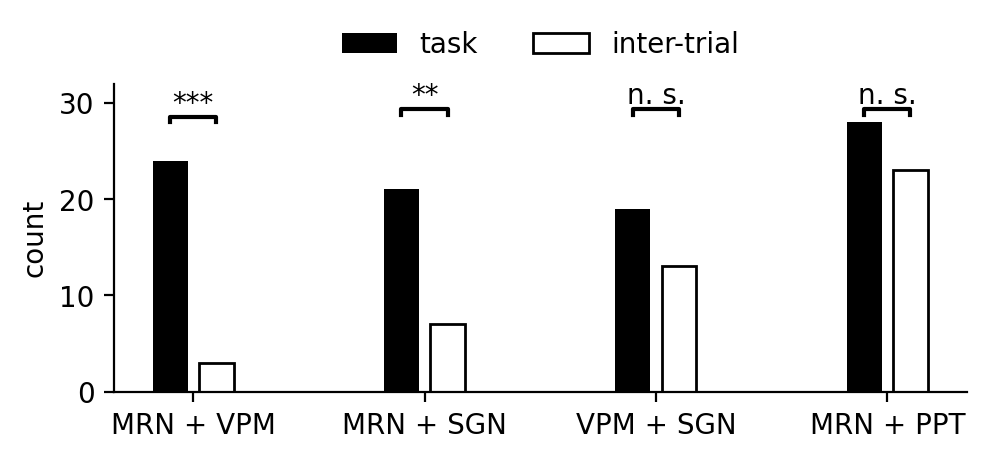

In [ ]:
plt.figure(figsize=(5.5, 2), dpi=200)
x_ii = 0
br_ticks = []
for br_group in [['MRN', 'VPM'], ['MRN', 'SGN'], ['VPM', 'SGN'], ['MRN', 'PPT']]:

    if x_ii == 0:
        plt.bar([x_ii - 0.1], [counts_dict[br_group[0] + '+' + br_group[1]]['s1']], color='black', width=0.15, label='task')
        plt.bar([x_ii + 0.1], [counts_dict[br_group[0] + '+' + br_group[1]]['s2']], color='white', width=0.15, edgecolor='black', label='inter-trial')

    else:
        plt.bar([x_ii - 0.1], [counts_dict[br_group[0] + '+' + br_group[1]]['s1']], color='black', width=0.15)
        plt.bar([x_ii + 0.1], [counts_dict[br_group[0] + '+' + br_group[1]]['s2']], color='white', width=0.15, edgecolor='black')

    barplot_annotate_brackets(1, 2, counts_dict[br_group[0] + '+' + br_group[1]]['p'],
                              np.array([x_ii - 0.1, x_ii - 0.1, x_ii + 0.1, x_ii + 0.1]),
                          [25.5, 25.5, 25.5, 25.5], dh=0.1, barh=.02, maxasterix=3)
    plt.xticks([x_ii], [br_group[0] + ' + ' + br_group[1]], rotation=30)
    # plt.xlim([0.3, 2.7])
    plt.ylim([0, 32])
    plt.ylabel('count')
    # plt.title(br_group[0] + ' + ' + br_group[1])
    x_ii += 1
    br_ticks.append(br_group[0] + ' + ' + br_group[1])

plt.xticks([0, 1, 2, 3], br_ticks, rotation=0)
plt.legend(loc='lower center', bbox_to_anchor=(0.5, 1), ncol=2, frameon=False)
sns.despine()
plt.show()

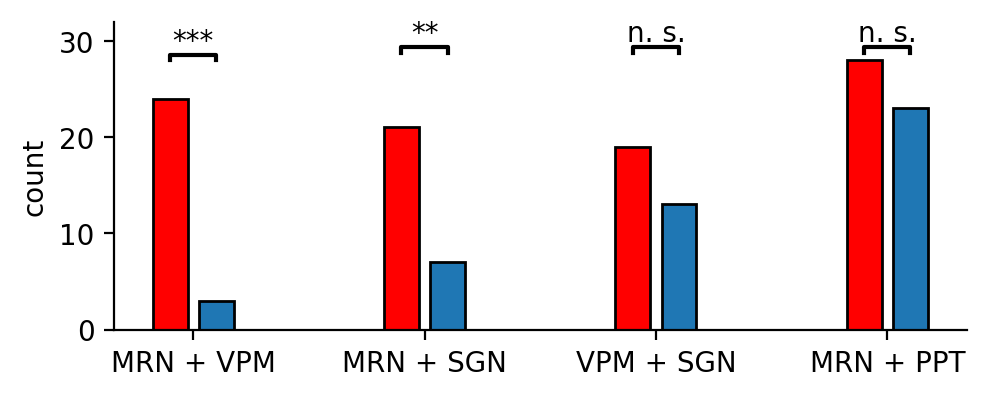

In [25]:
plt.figure(figsize=(5.5, 2), dpi=200)
x_ii = 0
br_ticks = []
for br_group in [['MRN', 'VPM'], ['MRN', 'SGN'], ['VPM', 'SGN'], ['MRN', 'PPT']]:

    if x_ii == 0:
        plt.bar([x_ii - 0.1], [counts_dict[br_group[0] + '+' + br_group[1]]['s1']], color='red', width=0.15, edgecolor='black', label='task')
        plt.bar([x_ii + 0.1], [counts_dict[br_group[0] + '+' + br_group[1]]['s2']], color='tab:blue', width=0.15, edgecolor='black', label='inter-trial')

    else:
        plt.bar([x_ii - 0.1], [counts_dict[br_group[0] + '+' + br_group[1]]['s1']], color='red', width=0.15, edgecolor='black')
        plt.bar([x_ii + 0.1], [counts_dict[br_group[0] + '+' + br_group[1]]['s2']], color='tab:blue', width=0.15, edgecolor='black')

    barplot_annotate_brackets(1, 2, counts_dict[br_group[0] + '+' + br_group[1]]['p'],
                              np.array([x_ii - 0.1, x_ii - 0.1, x_ii + 0.1, x_ii + 0.1]),
                          [25.5, 25.5, 25.5, 25.5], dh=0.1, barh=.02, maxasterix=3)
    plt.xticks([x_ii], [br_group[0] + ' + ' + br_group[1]], rotation=30)
    # plt.xlim([0.3, 2.7])
    plt.ylim([0, 32])
    plt.ylabel('count')
    # plt.title(br_group[0] + ' + ' + br_group[1])
    x_ii += 1
    br_ticks.append(br_group[0] + ' + ' + br_group[1])

plt.xticks([0, 1, 2, 3], br_ticks, rotation=0)
# plt.legend(loc='lower center', bbox_to_anchor=(0.5, 1), ncol=2, frameon=False)
sns.despine()
plt.savefig("/content/drive/MyDrive/Project/BrainRegionId/Nature/pics/MRN_SGN.pdf", format="pdf", bbox_inches="tight")
plt.show()


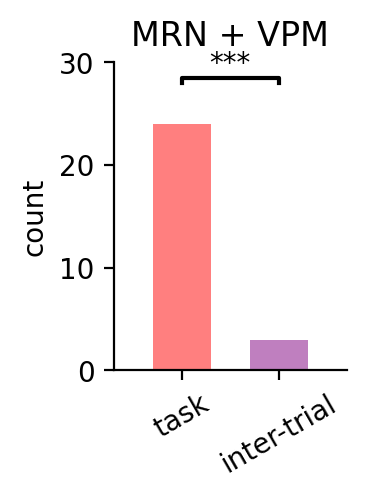

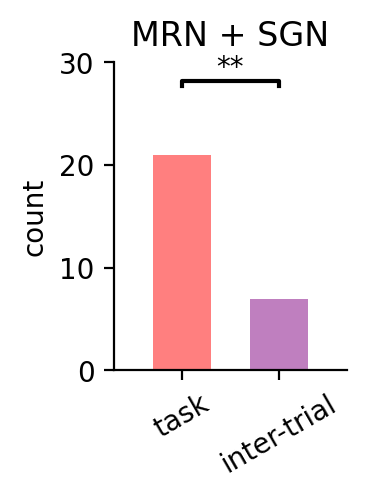

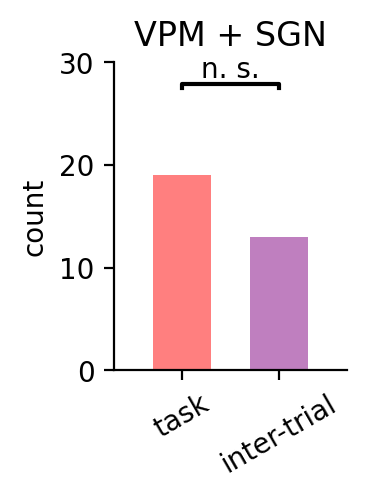

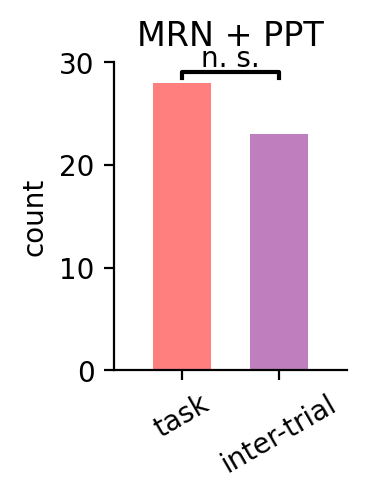

In [ ]:
for br_group in [['MRN', 'VPM'], ['MRN', 'SGN'], ['VPM', 'SGN'], ['MRN', 'PPT']]:
    plt.figure(figsize=(1.5, 2), dpi=200)
    plt.bar([1], [counts_dict[br_group[0] + '+' + br_group[1]]['s1']], color='red', width=0.6, alpha=0.5)
    plt.bar([2], [counts_dict[br_group[0] + '+' + br_group[1]]['s2']], color='purple', width=0.6, alpha=0.5)
    barplot_annotate_brackets(1, 2, counts_dict[br_group[0] + '+' + br_group[1]]['p'], np.array([1, 1, 2, 2]),
                          [25.5, 25.5, 25.5, 25.5], dh=0.1, barh=.02, maxasterix=3)
    plt.xticks([1, 2], ['task', 'inter-trial'], rotation=30)
    plt.xlim([0.3, 2.7])
    plt.ylim([0, 30])
    plt.ylabel('count')
    plt.title(br_group[0] + ' + ' + br_group[1])
    sns.despine()
    plt.show()

In [13]:
counts_dict = {}
for br_group in [['CP', 'MOp6a'], ['CP', 'MOp6b'], ['MOp6a', 'MOp6b'], ['CP', 'ACAd5']]:

    counts_dict[br_group[0] + '+' + br_group[1]] = {}
    key = 'stimOn_times'
    exist_flag = []
    for rep in range(0, 30):
        community_dict = community_keys_repeat_dict[key][rep]
        try:
            group_label = [community_dict['communities_label'][np.argwhere(community_dict['communities_acronym'] == acronym).flatten()] for acronym in br_group]
            if len(np.unique(np.array(group_label))) == 1:
                exist_flag.append(1)
            else:
                exist_flag.append(0)

        except:
            exist_flag.append(0)
            continue

    s1 = np.array(exist_flag).sum()

    key = 'stimOff_times'
    exist_flag = []
    for rep in range(0, 30):
        community_dict = community_keys_repeat_dict[key][rep]
        try:
            group_label = [community_dict['communities_label'][np.argwhere(community_dict['communities_acronym'] == acronym).flatten()] for acronym in br_group]
            if len(np.unique(np.array(group_label))) == 1:
                exist_flag.append(1)
            else:
                exist_flag.append(0)

        except:
            exist_flag.append(0)
            continue

    s2 = np.array(exist_flag).sum()

    # Sample data:
    count1, nobs1 = s1, 30
    count2, nobs2 = s2, 30

    # Create a 2x2 contingency table:
    # Row 1: successes and failures for group 1
    # Row 2: successes and failures for group 2
    table = np.array([
        [count1, nobs1 - count1],
        [count2, nobs2 - count2]
    ])

    # Perform Fisher's exact test
    # The alternative hypothesis can be 'two-sided', 'less', or 'greater'.
    odds_ratio, p_value = fisher_exact(table, alternative='two-sided')

    print(f"Odds Ratio: {odds_ratio}")
    print(f"P-value: {p_value}")

    # Interpretation:
    alpha = 0.05
    if p_value < alpha:
        print("Reject the null hypothesis: there is a significant difference between the two proportions.")
    else:
        print("Fail to reject the null hypothesis: there is not enough evidence to suggest a significant difference between the two proportions.")

    counts_dict[br_group[0] + '+' + br_group[1]]['s1'] = s1
    counts_dict[br_group[0] + '+' + br_group[1]]['s2'] = s2
    counts_dict[br_group[0] + '+' + br_group[1]]['p'] = p_value

Odds Ratio: 0.2894736842105263
P-value: 0.0378872128952835
Reject the null hypothesis: there is a significant difference between the two proportions.
Odds Ratio: 0.2894736842105263
P-value: 0.0378872128952835
Reject the null hypothesis: there is a significant difference between the two proportions.
Odds Ratio: nan
P-value: 1.0
Fail to reject the null hypothesis: there is not enough evidence to suggest a significant difference between the two proportions.
Odds Ratio: 1.1428571428571428
P-value: 1.0
Fail to reject the null hypothesis: there is not enough evidence to suggest a significant difference between the two proportions.


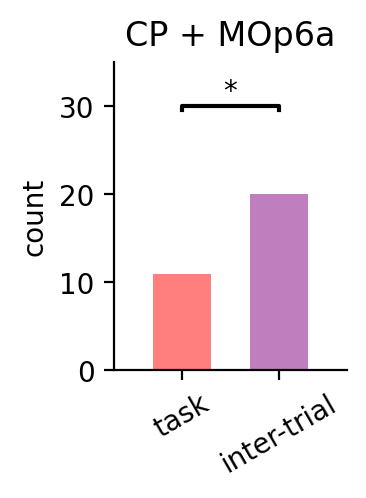

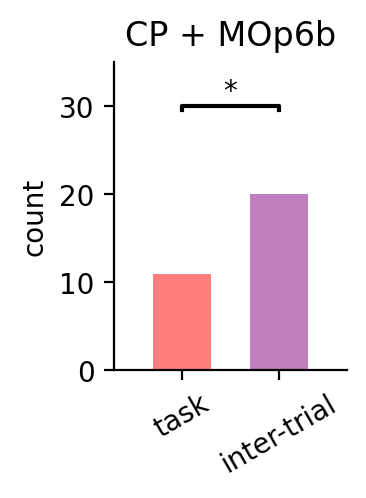

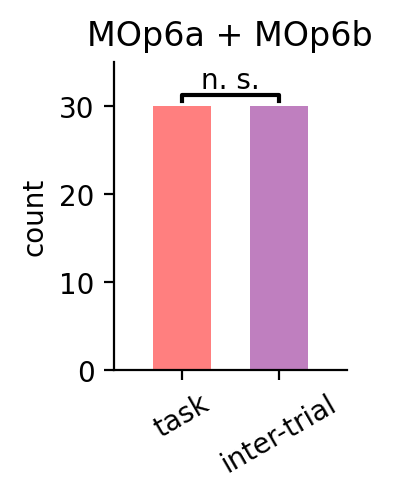

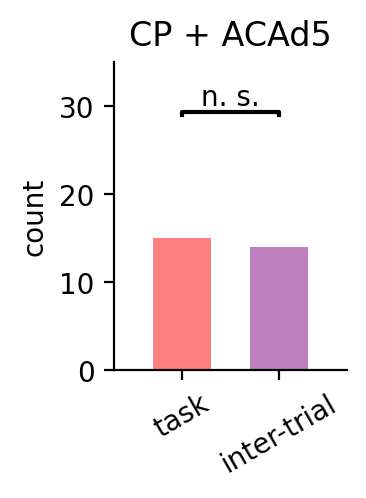

In [ ]:
for br_group in [['CP', 'MOp6a'], ['CP', 'MOp6b'], ['MOp6a', 'MOp6b'], ['CP', 'ACAd5']]:
    plt.figure(figsize=(1.5, 2), dpi=200)
    plt.bar([1], [counts_dict[br_group[0] + '+' + br_group[1]]['s1']], color='red', width=0.6, alpha=0.5)
    plt.bar([2], [counts_dict[br_group[0] + '+' + br_group[1]]['s2']], color='purple', width=0.6, alpha=0.5)
    barplot_annotate_brackets(1, 2, counts_dict[br_group[0] + '+' + br_group[1]]['p'], np.array([1, 1, 2, 2]),
                          [27.5, 27.5, 27.5, 27.5], dh=0.1, barh=.02, maxasterix=3)
    plt.xticks([1, 2], ['task', 'inter-trial'], rotation=30)
    plt.xlim([0.3, 2.7])
    plt.ylim([0, 35])
    plt.ylabel('count')
    plt.title(br_group[0] + ' + ' + br_group[1])
    sns.despine()
    plt.show()

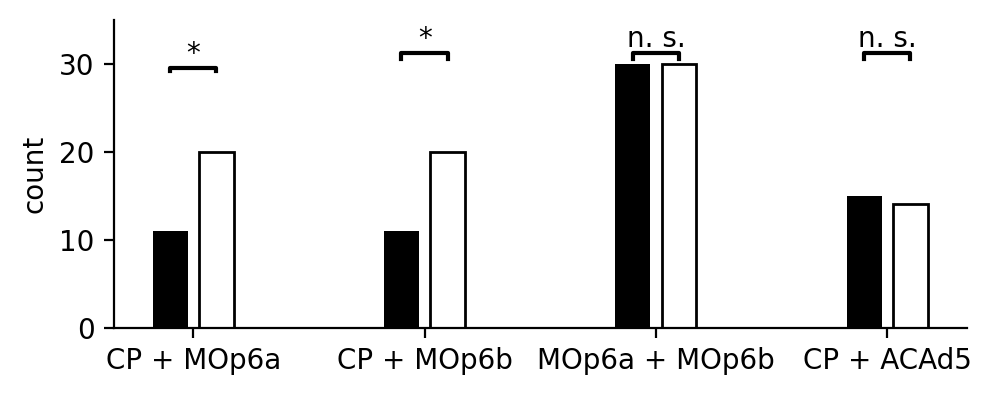

In [ ]:
plt.figure(figsize=(5.5, 2), dpi=200)
x_ii = 0
br_ticks = []
for br_group in [['CP', 'MOp6a'], ['CP', 'MOp6b'], ['MOp6a', 'MOp6b'], ['CP', 'ACAd5']]:

    if x_ii == 0:
        plt.bar([x_ii - 0.1], [counts_dict[br_group[0] + '+' + br_group[1]]['s1']], color='black', width=0.15, label='task')
        plt.bar([x_ii + 0.1], [counts_dict[br_group[0] + '+' + br_group[1]]['s2']], color='white', width=0.15, edgecolor='black', label='inter-trial')

    else:
        plt.bar([x_ii - 0.1], [counts_dict[br_group[0] + '+' + br_group[1]]['s1']], color='black', width=0.15)
        plt.bar([x_ii + 0.1], [counts_dict[br_group[0] + '+' + br_group[1]]['s2']], color='white', width=0.15, edgecolor='black')

    barplot_annotate_brackets(1, 2, counts_dict[br_group[0] + '+' + br_group[1]]['p'],
                              np.array([x_ii - 0.1, x_ii - 0.1, x_ii + 0.1, x_ii + 0.1]),
                          [27.0, 27.0, 27.0, 27.0], dh=0.1, barh=.02, maxasterix=3)
    plt.xticks([x_ii], [br_group[0] + ' + ' + br_group[1]], rotation=30)
    # plt.xlim([0.3, 2.7])
    plt.ylim([0, 35])
    plt.ylabel('count')
    # plt.title(br_group[0] + ' + ' + br_group[1])
    x_ii += 1
    br_ticks.append(br_group[0] + ' + ' + br_group[1])

plt.xticks([0, 1, 2, 3], br_ticks, rotation=0)
# plt.legend(loc='lower right')
sns.despine()
plt.show()

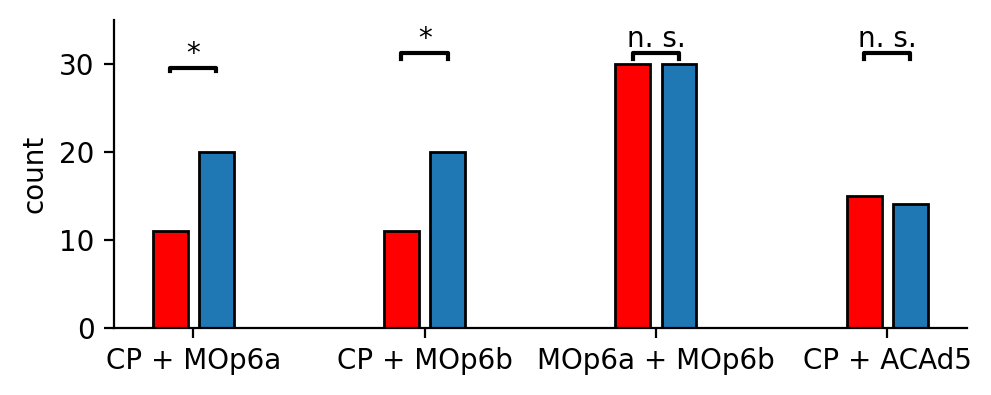

In [22]:
plt.figure(figsize=(5.5, 2), dpi=200)
x_ii = 0
br_ticks = []
for br_group in [['CP', 'MOp6a'], ['CP', 'MOp6b'], ['MOp6a', 'MOp6b'], ['CP', 'ACAd5']]:

    if x_ii == 0:
        plt.bar([x_ii - 0.1], [counts_dict[br_group[0] + '+' + br_group[1]]['s1']], color='red', width=0.15, edgecolor='black', label='task')
        plt.bar([x_ii + 0.1], [counts_dict[br_group[0] + '+' + br_group[1]]['s2']], color='tab:blue', width=0.15, edgecolor='black', label='inter-trial')

    else:
        plt.bar([x_ii - 0.1], [counts_dict[br_group[0] + '+' + br_group[1]]['s1']], color='red', width=0.15, edgecolor='black')
        plt.bar([x_ii + 0.1], [counts_dict[br_group[0] + '+' + br_group[1]]['s2']], color='tab:blue', width=0.15, edgecolor='black')

    barplot_annotate_brackets(1, 2, counts_dict[br_group[0] + '+' + br_group[1]]['p'],
                              np.array([x_ii - 0.1, x_ii - 0.1, x_ii + 0.1, x_ii + 0.1]),
                          [27.0, 27.0, 27.0, 27.0], dh=0.1, barh=.02, maxasterix=3)
    plt.xticks([x_ii], [br_group[0] + ' + ' + br_group[1]], rotation=30)
    # plt.xlim([0.3, 2.7])
    plt.ylim([0, 35])
    plt.ylabel('count')
    # plt.title(br_group[0] + ' + ' + br_group[1])
    x_ii += 1
    br_ticks.append(br_group[0] + ' + ' + br_group[1])

plt.xticks([0, 1, 2, 3], br_ticks, rotation=0)
# plt.legend(loc='lower right')
sns.despine()
plt.savefig("/content/drive/MyDrive/Project/BrainRegionId/Nature/pics/CP_MOp6a.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [ ]:
G = nx.from_numpy_array(copy.deepcopy(Mat_dict_rest['AnyNet']))
G.degree()

DegreeView({0: 8, 1: 38, 2: 20, 3: 43, 4: 52, 5: 135, 6: 154, 7: 74, 8: 62, 9: 47, 10: 103, 11: 168, 12: 126, 13: 40, 14: 2, 15: 20, 16: 50, 17: 61, 18: 74, 19: 18, 20: 53, 21: 59, 22: 58, 23: 74, 24: 140, 25: 51, 26: 41, 27: 54, 28: 61, 29: 71, 30: 70, 31: 23, 32: 0, 33: 19, 34: 35, 35: 61, 36: 70, 37: 48, 38: 31, 39: 65, 40: 80, 41: 90, 42: 86, 43: 29, 44: 43, 45: 67, 46: 56, 47: 75, 48: 109, 49: 26, 50: 27, 51: 51, 52: 19, 53: 30, 54: 40, 55: 8, 56: 34, 57: 43, 58: 87, 59: 101, 60: 52, 61: 18, 62: 25, 63: 55, 64: 32, 65: 8, 66: 0, 67: 0, 68: 22, 69: 19, 70: 0, 71: 0, 72: 0, 73: 67, 74: 0, 75: 0, 76: 10, 77: 11, 78: 18, 79: 0, 80: 51, 81: 14, 82: 12, 83: 9, 84: 0, 85: 7, 86: 5, 87: 43, 88: 59, 89: 43, 90: 56, 91: 67, 92: 32, 93: 33, 94: 57, 95: 51, 96: 106, 97: 69, 98: 22, 99: 87, 100: 101, 101: 59, 102: 180, 103: 123, 104: 67, 105: 17, 106: 2, 107: 15, 108: 75, 109: 30, 110: 38, 111: 48, 112: 49, 113: 57, 114: 88, 115: 22, 116: 21, 117: 19, 118: 53, 119: 59, 120: 22, 121: 15, 122: 1

In [ ]:
resolution = 1.0

community_keys_repeat_dict = {}

for key in ['stimOn_times', 'stimOff_times']:

    dat_tem = {}
    for rep in range(0, 30):
        if key == 'stimOn_times':
            Mat_dict = Mat_dict_stim_repeat

        elif key == 'stimOff_times':
            Mat_dict = Mat_dict_rest_repeat


        community_number = []
        community_index = {}
        community_dat = {}
        degree_dat = {}
        for name in ['AnyNet', 'ViT', 'RNN']:
            G = nx.from_numpy_array(copy.deepcopy(Mat_dict[rep][name]))
            degree_dat[name] = G.degree(weight='weight')
            X = copy.deepcopy(Mat_dict[rep][name])
            community_label, acronym_label, index = modularity_separation(X, resolution)
            community_number.append(len(np.unique(community_label)))
            community_index[name] = community_label

        communities = []
        communities_label = []
        communities_acronym = []
        ii = 0
        for community_ii_AnyNet in range(0, community_number[0]):
            for community_ii_ViT in range(0, community_number[1]):
                for community_ii_RNN in range(0, community_number[2]):
                    community0 = np.intersect1d(np.intersect1d(np.argwhere(community_index['AnyNet'] == community_ii_AnyNet).flatten(),
                                                    np.argwhere(community_index['ViT'] == community_ii_ViT).flatten()),
                                    np.argwhere(community_index['RNN'] == community_ii_RNN).flatten())
                    if len(community0) > 2:
                        communities.append(community0)
                        communities_acronym.append(np.array(acronym_list)[community0])
                        communities_label.append(ii * np.ones_like(community0))
                        ii = ii + 1

        communities = np.concat(communities)
        communities_label = np.concat(communities_label)
        communities_acronym = np.concat(communities_acronym)
        community_dat['communities'] = communities
        community_dat['communities_label'] = communities_label
        community_dat['communities_acronym'] = communities_acronym


        dat_tem[rep] = {}
        dat_tem[rep]['comm'] = community_dat
        dat_tem[rep]['degree'] = degree_dat



    community_keys_repeat_dict[key] = dat_tem



In [ ]:
count_states = {}
for key in ['stimOn_times', 'stimOff_times']:
    count_states[key] = {}
    counts = []
    for rep in range(0, 30):

        layer_counts = {}
        hub_acronyms = []
        for comm in np.unique(community_keys_repeat_dict[key][rep]['comm']['communities_label']):
            comm_acronyms = community_keys_repeat_dict[key][rep]['comm']['communities_acronym'][np.argwhere(community_keys_repeat_dict[key][rep]['comm']['communities_label'] == comm).flatten()]
            comm_ids = community_keys_repeat_dict[key][rep]['comm']['communities'][np.argwhere(community_keys_repeat_dict[key][rep]['comm']['communities_label'] == comm).flatten()]
            comm_degrees = []
            for id in comm_ids:
                comm_degrees.append(max(community_keys_repeat_dict[key][rep]['degree']['AnyNet'][id], community_keys_repeat_dict[key][rep]['degree']['ViT'][id], community_keys_repeat_dict[key][rep]['degree']['RNN'][id]))
            hub_acronyms.append(comm_acronyms[np.argmax(np.array(comm_degrees)).flatten()])
        hub_acronyms = np.array(hub_acronyms)
        layer_counter1 = 0
        layer_counter3 = 0
        layer_counter4 = 0
        layer_counter5 = 0
        layer_counter6a = 0
        layer_counter6b = 0

        for acronym in hub_acronyms:
            if '1' in acronym[0]:
                layer_counter1 += 1

            elif '3' in acronym[0]:
                layer_counter3 += 1

            elif '4' in acronym[0]:
                layer_counter4 += 1

            elif '5' in acronym[0]:
                layer_counter5 += 1

            elif '6a' in acronym[0]:
                layer_counter6a += 1

            elif '6b' in acronym[0]:
                layer_counter6b += 1

        layer_counts['1'] = layer_counter1
        layer_counts['3'] = layer_counter3
        layer_counts['4'] = layer_counter4
        layer_counts['5'] = layer_counter5
        layer_counts['6a'] = layer_counter6a
        layer_counts['6b'] = layer_counter6b

        count_states[key][rep] = layer_counts


In [ ]:
count_states[key][rep]

{'1': 5, '3': 4, '4': 1, '5': 10, '6a': 4, '6b': 0}

In [ ]:
count_states['stimOn_times']

{29: {'1': 3, '3': 4, '4': 1, '5': 7, '6a': 5, '6b': 0}}

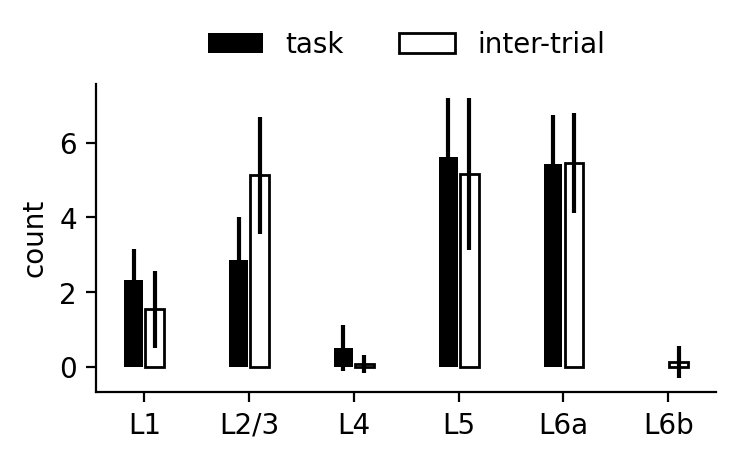

In [ ]:
plt.figure(figsize=(4, 2), dpi=200)
x_ii = 0
br_ticks = []
for layer in ['1', '3', '4', '5', '6a', '6b']:
    countOn = np.array([count_states['stimOn_times'][rep][layer] for rep in range(0, 30)])
    countOff = np.array([count_states['stimOff_times'][rep][layer] for rep in range(0, 30)])

    if x_ii == 0:
        plt.bar([x_ii - 0.1], [countOn.mean()], yerr=[countOn.std()], color='black', width=0.18, label='task')
        plt.bar([x_ii + 0.1], [countOff.mean()], yerr=[countOff.std()], color='white', width=0.18, edgecolor='black', label='inter-trial')

    else:
        plt.bar([x_ii - 0.1], [countOn.mean()], yerr=[countOn.std()], color='black', width=0.18)
        plt.bar([x_ii + 0.1], [countOff.mean()], yerr=[countOff.std()], color='white', width=0.18, edgecolor='black')

    # barplot_annotate_brackets(1, 2, counts_dict[br_group[0] + '+' + br_group[1]]['p'],
    #                           np.array([x_ii - 0.1, x_ii - 0.1, x_ii + 0.1, x_ii + 0.1]),
    #                       [27.0, 27.0, 27.0, 27.0], dh=0.1, barh=.02, maxasterix=3)
    # plt.xticks([x_ii], [br_group[0] + ' + ' + br_group[1]], rotation=30)
    # plt.xlim([0.3, 2.7])
    # plt.ylim([0, 35])
    plt.ylabel('count')
    # plt.title(br_group[0] + ' + ' + br_group[1])
    x_ii += 1

br_ticks = ['L1', 'L2/3', 'L4', 'L5', 'L6a', 'L6b']
plt.xticks([0, 1, 2, 3, 4, 5], br_ticks, rotation=0)
plt.legend(loc='lower center', bbox_to_anchor=(0.5, 1), ncol=2, frameon=False)
sns.despine()
plt.show()

In [ ]:
del count_states
count_states = {}
for key in ['stimOn_times', 'stimOff_times']:
    count_states[key] = {}
    counts = []
    for rep in range(0, 30):

        layer_counts = {}
        hub_acronyms = []
        comm_acronyms = community_keys_repeat_dict[key][rep]['comm']['communities_acronym']

        layer_counter1 = 0
        layer_counter3 = 0
        layer_counter4 = 0
        layer_counter5 = 0
        layer_counter6a = 0
        layer_counter6b = 0


        for acronym in comm_acronyms:
            if '1' in acronym:
                layer_counter1 += 1

            elif '3' in acronym:
                layer_counter3 += 1

            elif '4' in acronym:
                layer_counter4 += 1

            elif '5' in acronym:
                layer_counter5 += 1

            elif '6a' in acronym:
                layer_counter6a += 1

            elif '6b' in acronym:
                layer_counter6b += 1

        layer_counts['1'] = layer_counter1
        layer_counts['3'] = layer_counter3
        layer_counts['4'] = layer_counter4
        layer_counts['5'] = layer_counter5
        layer_counts['6a'] = layer_counter6a
        layer_counts['6b'] = layer_counter6b

        count_states[key][rep] = layer_counts




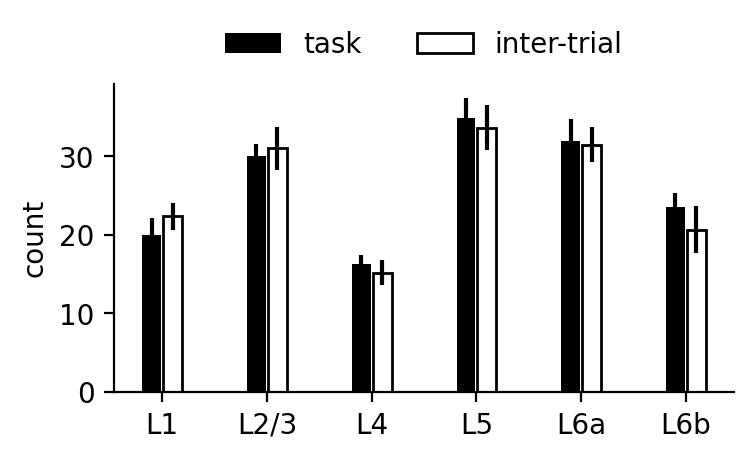

In [ ]:
plt.figure(figsize=(4, 2), dpi=200)
x_ii = 0
br_ticks = []
for layer in ['1', '3', '4', '5', '6a', '6b']:
    countOn = np.array([count_states['stimOn_times'][rep][layer] for rep in range(0, 30)])
    countOff = np.array([count_states['stimOff_times'][rep][layer] for rep in range(0, 30)])

    if x_ii == 0:
        plt.bar([x_ii - 0.1], [countOn.mean()], yerr=[countOn.std()], color='black', width=0.18, label='task')
        plt.bar([x_ii + 0.1], [countOff.mean()], yerr=[countOff.std()], color='white', width=0.18, edgecolor='black', label='inter-trial')

    else:
        plt.bar([x_ii - 0.1], [countOn.mean()], yerr=[countOn.std()], color='black', width=0.18)
        plt.bar([x_ii + 0.1], [countOff.mean()], yerr=[countOff.std()], color='white', width=0.18, edgecolor='black')

    # barplot_annotate_brackets(1, 2, counts_dict[br_group[0] + '+' + br_group[1]]['p'],
    #                           np.array([x_ii - 0.1, x_ii - 0.1, x_ii + 0.1, x_ii + 0.1]),
    #                       [27.0, 27.0, 27.0, 27.0], dh=0.1, barh=.02, maxasterix=3)
    # plt.xticks([x_ii], [br_group[0] + ' + ' + br_group[1]], rotation=30)
    # plt.xlim([0.3, 2.7])
    # plt.ylim([0, 35])
    plt.ylabel('count')
    # plt.title(br_group[0] + ' + ' + br_group[1])
    x_ii += 1

br_ticks = ['L1', 'L2/3', 'L4', 'L5', 'L6a', 'L6b']
plt.xticks([0, 1, 2, 3, 4, 5], br_ticks, rotation=0)
plt.legend(loc='lower center', bbox_to_anchor=(0.5, 1), ncol=2, frameon=False)
sns.despine()
plt.show()

In [ ]:
resolution = 1.0

community_keys_repeat_dict = {}

for key in ['stimOn_times', 'stimOff_times']:

    dat_tem = {}
    for rep in range(0, 30):
        if key == 'stimOn_times':
            Mat_dict = Mat_dict_stim_repeat

        elif key == 'stimOff_times':
            Mat_dict = Mat_dict_rest_repeat


        community_number = []
        community_index = {}
        community_dat = {}
        degree_dat = {}
        confusion_dat = {}
        for name in ['AnyNet', 'ViT', 'RNN']:
            G = nx.from_numpy_array(copy.deepcopy(Mat_dict[rep][name]))
            degree_dat[name] = G.degree(weight='weight')
            confusion_dat[name] = copy.deepcopy(Mat_dict[rep][name])
            X = copy.deepcopy(Mat_dict[rep][name])
            community_label, acronym_label, index = modularity_separation(X, resolution)
            community_number.append(len(np.unique(community_label)))
            community_index[name] = community_label

        communities = []
        communities_label = []
        communities_acronym = []
        ii = 0
        for community_ii_AnyNet in range(0, community_number[0]):
            for community_ii_ViT in range(0, community_number[1]):
                for community_ii_RNN in range(0, community_number[2]):
                    community0 = np.intersect1d(np.intersect1d(np.argwhere(community_index['AnyNet'] == community_ii_AnyNet).flatten(),
                                                    np.argwhere(community_index['ViT'] == community_ii_ViT).flatten()),
                                    np.argwhere(community_index['RNN'] == community_ii_RNN).flatten())
                    if len(community0) > 2:
                        communities.append(community0)
                        communities_acronym.append(np.array(acronym_list)[community0])
                        communities_label.append(ii * np.ones_like(community0))
                        ii = ii + 1

        communities = np.concat(communities)
        communities_label = np.concat(communities_label)
        communities_acronym = np.concat(communities_acronym)
        community_dat['communities'] = communities
        community_dat['communities_label'] = communities_label
        community_dat['communities_acronym'] = communities_acronym


        dat_tem[rep] = {}
        dat_tem[rep]['comm'] = community_dat
        dat_tem[rep]['degree'] = degree_dat
        dat_tem[rep]['confusion'] = confusion_dat



    community_keys_repeat_dict[key] = dat_tem


In [ ]:
count_states = {}
for key in ['stimOn_times', 'stimOff_times']:
    count_states[key] = {}
    counts = []
    for rep in range(0, 30):

        comm_ids = community_keys_repeat_dict[key][rep]['comm']['communities']
        connection = []
        for ii, id_ii in enumerate(comm_ids):
            connection0 = []
            for jj, id_jj in enumerate(comm_ids):
                if community_keys_repeat_dict[key][rep]['comm']['communities_label'][ii] == community_keys_repeat_dict[key][rep]['comm']['communities_label'][jj]:
                    continue
                else:
                    anynet_max = max(community_keys_repeat_dict[key][rep]['confusion']['AnyNet'][id_jj, id_ii], community_keys_repeat_dict[key][rep]['confusion']['AnyNet'][id_ii, id_jj])
                    vit_max = max(community_keys_repeat_dict[key][rep]['confusion']['ViT'][id_jj, id_ii], community_keys_repeat_dict[key][rep]['confusion']['ViT'][id_ii, id_jj])
                    rnn_max = max(community_keys_repeat_dict[key][rep]['confusion']['RNN'][id_jj, id_ii], community_keys_repeat_dict[key][rep]['confusion']['RNN'][id_ii, id_jj])
                    connection0.append(max(anynet_max, vit_max, rnn_max))


            connection.append(np.array(connection0).max())

        acronym_connection = np.array(connection)

        connector_acronym = community_keys_repeat_dict[key][rep]['comm']['communities_acronym'][np.argwhere(acronym_connection > 0.15).flatten()]

        layer_counter1 = 0
        layer_counter3 = 0
        layer_counter4 = 0
        layer_counter5 = 0
        layer_counter6a = 0
        layer_counter6b = 0


        for acronym in connector_acronym :
            if len(acronym) > 0:
                if '1' in acronym:
                    layer_counter1 += 1

                elif '3' in acronym:
                    layer_counter3 += 1

                elif '4' in acronym:
                    layer_counter4 += 1

                elif '5' in acronym:
                    layer_counter5 += 1

                elif '6a' in acronym:
                    layer_counter6a += 1

                elif '6b' in acronym:
                    layer_counter6b += 1

        layer_counts = {}
        layer_counts['1'] = layer_counter1
        layer_counts['3'] = layer_counter3
        layer_counts['4'] = layer_counter4
        layer_counts['5'] = layer_counter5
        layer_counts['6a'] = layer_counter6a
        layer_counts['6b'] = layer_counter6b

        count_states[key][rep] = layer_counts




In [ ]:
count_states = {}
for key in ['stimOn_times', 'stimOff_times']:
    count_states[key] = {}
    counts = []
    for rep in range(0, 30):

        comm_ids = community_keys_repeat_dict[key][rep]['comm']['communities']
        connection = []
        for ii, id_ii in enumerate(comm_ids):
            connection0 = []
            for jj, id_jj in enumerate(comm_ids):
                if community_keys_repeat_dict[key][rep]['comm']['communities_label'][ii] == community_keys_repeat_dict[key][rep]['comm']['communities_label'][jj]:
                    continue
                else:
                    anynet_max = max(community_keys_repeat_dict[key][rep]['confusion']['AnyNet'][id_jj, id_ii], community_keys_repeat_dict[key][rep]['confusion']['AnyNet'][id_ii, id_jj])
                    vit_max = max(community_keys_repeat_dict[key][rep]['confusion']['ViT'][id_jj, id_ii], community_keys_repeat_dict[key][rep]['confusion']['ViT'][id_ii, id_jj])
                    rnn_max = max(community_keys_repeat_dict[key][rep]['confusion']['RNN'][id_jj, id_ii], community_keys_repeat_dict[key][rep]['confusion']['RNN'][id_ii, id_jj])
                    connection0.append(max(anynet_max, vit_max, rnn_max))


            connection.append(np.array(connection0).max())

        acronym_connection = np.array(connection)
        connector_acronym = []
        for comm in np.unique(community_keys_repeat_dict[key][rep]['comm']['communities_label']):
            connection_selec = acronym_connection[np.argwhere(community_keys_repeat_dict[key][rep]['comm']['communities_label'] == comm).flatten()]
            comm_acronyms = community_keys_repeat_dict[key][rep]['comm']['communities_acronym'][np.argwhere(community_keys_repeat_dict[key][rep]['comm']['communities_label'] == comm).flatten()]
            connector_acronym.append(comm_acronyms[np.argwhere(connection_selec > 0.1).flatten()])


        # connector_acronym = np.array(connector_acronym)
        # print(connector_acronym)

        layer_counter1 = 0
        layer_counter3 = 0
        layer_counter4 = 0
        layer_counter5 = 0
        layer_counter6a = 0
        layer_counter6b = 0


        for acronym in connector_acronym :
            if len(acronym) > 0:
                if '1' in acronym:
                    layer_counter1 += 1

                elif '3' in acronym:
                    layer_counter3 += 1

                elif '4' in acronym:
                    layer_counter4 += 1

                elif '5' in acronym:
                    layer_counter5 += 1

                elif '6a' in acronym:
                    layer_counter6a += 1

                elif '6b' in acronym:
                    layer_counter6b += 1

        layer_counts = {}
        layer_counts['1'] = layer_counter1
        layer_counts['3'] = layer_counter3
        layer_counts['4'] = layer_counter4
        layer_counts['5'] = layer_counter5
        layer_counts['6a'] = layer_counter6a
        layer_counts['6b'] = layer_counter6b

        count_states[key][rep] = layer_counts





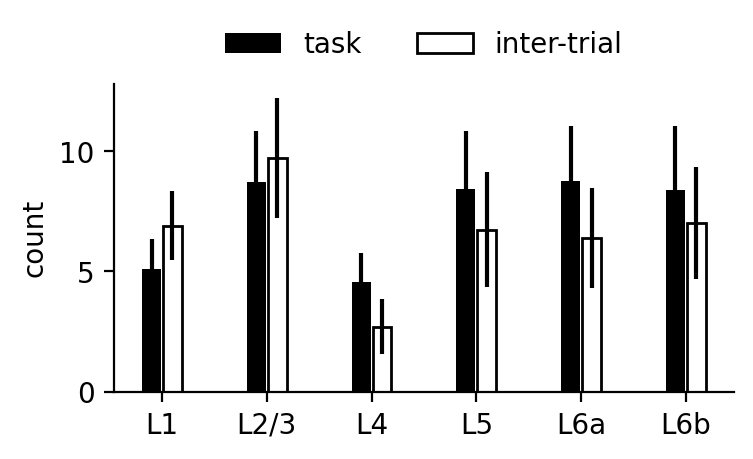

In [ ]:
plt.figure(figsize=(4, 2), dpi=200)
x_ii = 0
br_ticks = []
for layer in ['1', '3', '4', '5', '6a', '6b']:
    countOn = np.array([count_states['stimOn_times'][rep][layer] for rep in range(0, 30)])
    countOff = np.array([count_states['stimOff_times'][rep][layer] for rep in range(0, 30)])

    if x_ii == 0:
        plt.bar([x_ii - 0.1], [countOn.mean()], yerr=[countOn.std()], color='black', width=0.18, label='task')
        plt.bar([x_ii + 0.1], [countOff.mean()], yerr=[countOff.std()], color='white', width=0.18, edgecolor='black', label='inter-trial')

    else:
        plt.bar([x_ii - 0.1], [countOn.mean()], yerr=[countOn.std()], color='black', width=0.18)
        plt.bar([x_ii + 0.1], [countOff.mean()], yerr=[countOff.std()], color='white', width=0.18, edgecolor='black')

    # barplot_annotate_brackets(1, 2, counts_dict[br_group[0] + '+' + br_group[1]]['p'],
    #                           np.array([x_ii - 0.1, x_ii - 0.1, x_ii + 0.1, x_ii + 0.1]),
    #                       [27.0, 27.0, 27.0, 27.0], dh=0.1, barh=.02, maxasterix=3)
    # plt.xticks([x_ii], [br_group[0] + ' + ' + br_group[1]], rotation=30)
    # plt.xlim([0.3, 2.7])
    # plt.ylim([0, 35])
    plt.ylabel('count')
    # plt.title(br_group[0] + ' + ' + br_group[1])
    x_ii += 1

br_ticks = ['L1', 'L2/3', 'L4', 'L5', 'L6a', 'L6b']
plt.xticks([0, 1, 2, 3, 4, 5], br_ticks, rotation=0)
plt.legend(loc='lower center', bbox_to_anchor=(0.5, 1), ncol=2, frameon=False)
sns.despine()
plt.show()

In [ ]:
count_states = {}
for key in ['stimOn_times', 'stimOff_times']:
    count_states[key] = {}
    counts = []
    for rep in range(0, 30):

        layer_counts = {}
        hub_acronyms = []
        for comm in np.unique(community_keys_repeat_dict[key][rep]['comm']['communities_label']):
            comm_acronyms = community_keys_repeat_dict[key][rep]['comm']['communities_acronym'][np.argwhere(community_keys_repeat_dict[key][rep]['comm']['communities_label'] == comm).flatten()]
            comm_ids = community_keys_repeat_dict[key][rep]['comm']['communities'][np.argwhere(community_keys_repeat_dict[key][rep]['comm']['communities_label'] == comm).flatten()]
            comm_degrees = []
            for id in comm_ids:
                comm_degrees.append(max(community_keys_repeat_dict[key][rep]['degree']['AnyNet'][id], community_keys_repeat_dict[key][rep]['degree']['ViT'][id], community_keys_repeat_dict[key][rep]['degree']['RNN'][id]))
            hub_acronyms.append(comm_acronyms[np.argmax(np.array(comm_degrees)).flatten()])
        hub_acronyms = np.array(hub_acronyms)
        layer_counter1 = 0
        layer_counter3 = 0
        layer_counter4 = 0
        layer_counter5 = 0
        layer_counter6a = 0
        layer_counter6b = 0

        for acronym in hub_acronyms:
            if '1' in acronym[0]:
                layer_counter1 += 1

            elif '3' in acronym[0]:
                layer_counter3 += 1

            elif '4' in acronym[0]:
                layer_counter4 += 1

            elif '5' in acronym[0]:
                layer_counter5 += 1

            elif '6a' in acronym[0]:
                layer_counter6a += 1

            elif '6b' in acronym[0]:
                layer_counter6b += 1

        layer_counts['1'] = layer_counter1
        layer_counts['3'] = layer_counter3
        layer_counts['4'] = layer_counter4
        layer_counts['5'] = layer_counter5
        layer_counts['6a'] = layer_counter6a
        layer_counts['6b'] = layer_counter6b

        count_states[key][rep] = layer_counts

In [ ]:
community_dict_rest[resolution]['communities_acronym']

array(['KF', 'I5', 'DCO', 'VCO', 'CU', 'ECU', 'SPVC', 'SPVI', 'Pa5',
       'AMBv', 'GRN', 'ICB', 'IO', 'IRN', 'LIN', 'LRNm', 'MARN', 'MDRNd',
       'MDRNv', 'PARN', 'PAS', 'PGRNd', 'PGRNl', 'PRP', 'LAV', 'MV',
       'SPIV', 'x', 'y', 'FN', 'IP', 'DN', 'VeCB', 'NTS', 'SPVO', 'LING',
       'CENT2', 'CENT3', 'CUL4 5', 'DEC', 'FOTU', 'PYR', 'UVU', 'NOD',
       'SIM', 'ANcr1', 'ANcr2', 'PRM', 'COPY', 'PFL', 'FL', 'ICc', 'CUN',
       'SOCl', 'PRNc', 'SUT', 'PC5', 'FRP6a', 'MOp5', 'MOp6a', 'MOp6b',
       'MOs6a', 'MOs6b', 'SSp-m2/3', 'SSp-m4', 'SSp-m5', 'SSp-m6a',
       'SSp-m6b', 'GU5', 'GU6a', 'ACAd5', 'ACAd6a', 'ACAd6b', 'ACAv2/3',
       'ACAv5', 'ACAv6a', 'ACAv6b', 'PL5', 'PL6a', 'PL6b', 'ILA1',
       'ILA2/3', 'ILA5', 'ILA6a', 'ORBl6a', 'ORBm5', 'ORBm6a', 'ORBvl6a',
       'AId5', 'AId6a', 'AId6b', 'AIp6b', 'AIv2/3', 'AIv5', 'AIv6a',
       'AIv6b', 'CLA', 'EPd', 'CP', 'ACB', 'VISp1', 'VISp2/3', 'VISp4',
       'VISp5', 'VISp6a', 'VISpl5', 'VISpl6a', 'VISli2/3', 'RSPagl5',
    

In [ ]:
degree_dat = {}
for name in ['AnyNet', 'ViT', 'RNN']:
    G = nx.from_numpy_array(copy.deepcopy(Mat_dict_rest[name]))
    degree_dat[name] = G.degree()

layer_counts = {}
hub_acronyms = []
for comm in np.unique(community_dict_rest[resolution]['communities_label']):
    comm_acronyms = community_dict_rest[resolution]['communities_acronym'][np.argwhere(community_dict_rest[resolution]['communities_label'] == comm).flatten()]
    comm_ids = community_dict_rest[resolution]['communities'][np.argwhere(community_dict_rest[resolution]['communities_label'] == comm).flatten()]
    comm_degrees = []
    for id in comm_ids:
        comm_degrees.append(max(degree_dat['AnyNet'][id], degree_dat['ViT'][id], degree_dat['RNN'][id]))
    hub_acronyms.append(comm_acronyms[np.argmax(np.array(comm_degrees)).flatten()])
    print(f'community label: {comm}')
    print(f'community hub: {comm_acronyms[np.argmax(np.array(comm_degrees)).flatten()]}')
    print(f'community member: {comm_acronyms}')

hub_acronyms = np.array(hub_acronyms)

community label: 0
community hub: ['CUL4 5']
community member: ['KF' 'I5' 'DCO' 'VCO' 'CU' 'ECU' 'SPVC' 'SPVI' 'Pa5' 'AMBv' 'GRN' 'ICB'
 'IO' 'IRN' 'LIN' 'LRNm' 'MARN' 'MDRNd' 'MDRNv' 'PARN' 'PAS' 'PGRNd'
 'PGRNl' 'PRP' 'LAV' 'MV' 'SPIV' 'x' 'y' 'FN' 'IP' 'DN' 'VeCB' 'NTS'
 'SPVO' 'LING' 'CENT2' 'CENT3' 'CUL4 5' 'DEC' 'FOTU' 'PYR' 'UVU' 'NOD'
 'SIM' 'ANcr1' 'ANcr2' 'PRM' 'COPY' 'PFL' 'FL']
community label: 1
community hub: ['CUN']
community member: ['ICc' 'CUN' 'SOCl' 'PRNc' 'SUT' 'PC5']
community label: 2
community hub: ['CP']
community member: ['FRP6a' 'MOp5' 'MOp6a' 'MOp6b' 'MOs6a' 'MOs6b' 'SSp-m2/3' 'SSp-m4'
 'SSp-m5' 'SSp-m6a' 'SSp-m6b' 'GU5' 'GU6a' 'ACAd5' 'ACAd6a' 'ACAd6b'
 'ACAv2/3' 'ACAv5' 'ACAv6a' 'ACAv6b' 'PL5' 'PL6a' 'PL6b' 'ILA1' 'ILA2/3'
 'ILA5' 'ILA6a' 'ORBl6a' 'ORBm5' 'ORBm6a' 'ORBvl6a' 'AId5' 'AId6a' 'AId6b'
 'AIp6b' 'AIv2/3' 'AIv5' 'AIv6a' 'AIv6b' 'CLA' 'EPd' 'CP' 'ACB']
community label: 3
community hub: ['VISp5']
community member: ['VISp1' 'VISp2/3' 'VISp4' 'VISp5' '

In [ ]:
degree_dat = {}
for name in ['AnyNet', 'ViT', 'RNN']:
    G = nx.from_numpy_array(copy.deepcopy(Mat_dict_rest[name]))
    degree_dat[name] = G.degree()

layer_counts = {}
hub_acronyms = []
for comm in np.unique(community_dict_rest[resolution]['communities_label']):
    comm_acronyms = community_dict_rest[resolution]['communities_acronym'][np.argwhere(community_dict_rest[resolution]['communities_label'] == comm).flatten()]
    comm_ids = community_dict_rest[resolution]['communities'][np.argwhere(community_dict_rest[resolution]['communities_label'] == comm).flatten()]
    comm_degrees = []
    for id in comm_ids:
        comm_degrees.append(max(degree_dat['AnyNet'][id], degree_dat['ViT'][id], degree_dat['RNN'][id]))

    print(f'community label: {comm}')
    print(f'community hub: {comm_acronyms[np.argsort(np.array(comm_degrees)[-3:]).flatten()]}')
    print(f'community member: {comm_acronyms}')


community label: 0
community hub: ['DCO' 'KF' 'I5']
community member: ['KF' 'I5' 'DCO' 'VCO' 'CU' 'ECU' 'SPVC' 'SPVI' 'Pa5' 'AMBv' 'GRN' 'ICB'
 'IO' 'IRN' 'LIN' 'LRNm' 'MARN' 'MDRNd' 'MDRNv' 'PARN' 'PAS' 'PGRNd'
 'PGRNl' 'PRP' 'LAV' 'MV' 'SPIV' 'x' 'y' 'FN' 'IP' 'DN' 'VeCB' 'NTS'
 'SPVO' 'LING' 'CENT2' 'CENT3' 'CUL4 5' 'DEC' 'FOTU' 'PYR' 'UVU' 'NOD'
 'SIM' 'ANcr1' 'ANcr2' 'PRM' 'COPY' 'PFL' 'FL']
community label: 1
community hub: ['SOCl' 'ICc' 'CUN']
community member: ['ICc' 'CUN' 'SOCl' 'PRNc' 'SUT' 'PC5']
community label: 2
community hub: ['FRP6a' 'MOp6a' 'MOp5']
community member: ['FRP6a' 'MOp5' 'MOp6a' 'MOp6b' 'MOs6a' 'MOs6b' 'SSp-m2/3' 'SSp-m4'
 'SSp-m5' 'SSp-m6a' 'SSp-m6b' 'GU5' 'GU6a' 'ACAd5' 'ACAd6a' 'ACAd6b'
 'ACAv2/3' 'ACAv5' 'ACAv6a' 'ACAv6b' 'PL5' 'PL6a' 'PL6b' 'ILA1' 'ILA2/3'
 'ILA5' 'ILA6a' 'ORBl6a' 'ORBm5' 'ORBm6a' 'ORBvl6a' 'AId5' 'AId6a' 'AId6b'
 'AIp6b' 'AIv2/3' 'AIv5' 'AIv6a' 'AIv6b' 'CLA' 'EPd' 'CP' 'ACB']
community label: 3
community hub: ['VISp4' 'VISp1' 'VISp2/3'

In [ ]:
count_states = {}
for key in ['stimOn_times', 'stimOff_times']:
    count_states[key] = {}
    counts = []
    for rep in range(0, 30):

        layer_counts = {}
        hub_acronyms = []
        for comm in np.unique(community_keys_repeat_dict[key][rep]['comm']['communities_label']):
            comm_acronyms = community_keys_repeat_dict[key][rep]['comm']['communities_acronym'][np.argwhere(community_keys_repeat_dict[key][rep]['comm']['communities_label'] == comm).flatten()]
            comm_ids = community_keys_repeat_dict[key][rep]['comm']['communities'][np.argwhere(community_keys_repeat_dict[key][rep]['comm']['communities_label'] == comm).flatten()]
            comm_degrees = []
            for id in comm_ids:
                comm_degrees.append(max(community_keys_repeat_dict[key][rep]['degree']['AnyNet'][id], community_keys_repeat_dict[key][rep]['degree']['ViT'][id], community_keys_repeat_dict[key][rep]['degree']['RNN'][id]))
            hub_acronyms.append(comm_acronyms[np.argsort(np.array(comm_degrees)[-3:]).flatten()])
        hub_acronyms = np.array(hub_acronyms)
        layer_counter1 = 0
        layer_counter3 = 0
        layer_counter4 = 0
        layer_counter5 = 0
        layer_counter6a = 0
        layer_counter6b = 0

        for acronym_candi in hub_acronyms:
            for acronym in acronym_candi:
                if '1' in acronym:
                    layer_counter1 += 1

                elif '3' in acronym:
                    layer_counter3 += 1

                elif '4' in acronym:
                    layer_counter4 += 1

                elif '5' in acronym:
                    layer_counter5 += 1

                elif '6a' in acronym:
                    layer_counter6a += 1

                elif '6b' in acronym:
                    layer_counter6b += 1

        layer_counts['1'] = layer_counter1
        layer_counts['3'] = layer_counter3
        layer_counts['4'] = layer_counter4
        layer_counts['5'] = layer_counter5
        layer_counts['6a'] = layer_counter6a
        layer_counts['6b'] = layer_counter6b

        count_states[key][rep] = layer_counts


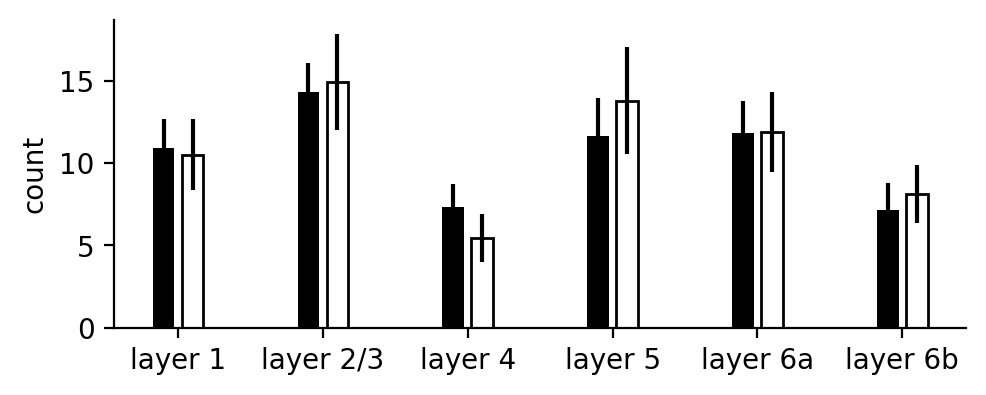

In [ ]:
plt.figure(figsize=(5.5, 2), dpi=200)
x_ii = 0
br_ticks = []
for layer in ['1', '3', '4', '5', '6a', '6b']:
    countOn = np.array([count_states['stimOn_times'][rep][layer] for rep in range(0, 30)])
    countOff = np.array([count_states['stimOff_times'][rep][layer] for rep in range(0, 30)])

    if x_ii == 0:
        plt.bar([x_ii - 0.1], [countOn.mean()], yerr=[countOn.std()], color='black', width=0.15, label='task')
        plt.bar([x_ii + 0.1], [countOff.mean()], yerr=[countOff.std()], color='white', width=0.15, edgecolor='black', label='inter-trial')

    else:
        plt.bar([x_ii - 0.1], [countOn.mean()], yerr=[countOn.std()], color='black', width=0.15)
        plt.bar([x_ii + 0.1], [countOff.mean()], yerr=[countOff.std()], color='white', width=0.15, edgecolor='black')

    # barplot_annotate_brackets(1, 2, counts_dict[br_group[0] + '+' + br_group[1]]['p'],
    #                           np.array([x_ii - 0.1, x_ii - 0.1, x_ii + 0.1, x_ii + 0.1]),
    #                       [27.0, 27.0, 27.0, 27.0], dh=0.1, barh=.02, maxasterix=3)
    # plt.xticks([x_ii], [br_group[0] + ' + ' + br_group[1]], rotation=30)
    # plt.xlim([0.3, 2.7])
    # plt.ylim([0, 35])
    plt.ylabel('count')
    # plt.title(br_group[0] + ' + ' + br_group[1])
    x_ii += 1

br_ticks = ['layer 1', 'layer 2/3', 'layer 4', 'layer 5', 'layer 6a', 'layer 6b']
plt.xticks([0, 1, 2, 3, 4, 5], br_ticks, rotation=0)
# plt.legend(loc='lower right')
sns.despine()
plt.show()

In [ ]:
count_states

{'stimOn_times': array([0.34883721, 0.44736842, 0.41666667, 0.44444444, 0.43589744,
        0.41935484, 0.45714286, 0.54545455, 0.51351351, 0.42105263,
        0.42857143, 0.48387097, 0.41025641, 0.4       , 0.48484848,
        0.5       , 0.475     , 0.44186047, 0.44117647, 0.54545455,
        0.51351351, 0.475     , 0.28571429, 0.44736842, 0.43243243,
        0.41666667, 0.42105263, 0.46153846, 0.45238095, 0.46511628]),
 'stimOff_times': array([0.45      , 0.425     , 0.53125   , 0.55263158, 0.3902439 ,
        0.47368421, 0.48571429, 0.38888889, 0.43902439, 0.39534884,
        0.44444444, 0.52631579, 0.5       , 0.45238095, 0.45833333,
        0.5       , 0.46511628, 0.46341463, 0.46666667, 0.43589744,
        0.58974359, 0.42105263, 0.51219512, 0.38888889, 0.5       ,
        0.46153846, 0.40540541, 0.39393939, 0.46666667, 0.51020408])}

In [ ]:
layer_p

TtestResult(statistic=np.float64(-1.150227294082584), pvalue=np.float64(0.2547707525638754), df=np.float64(58.0))

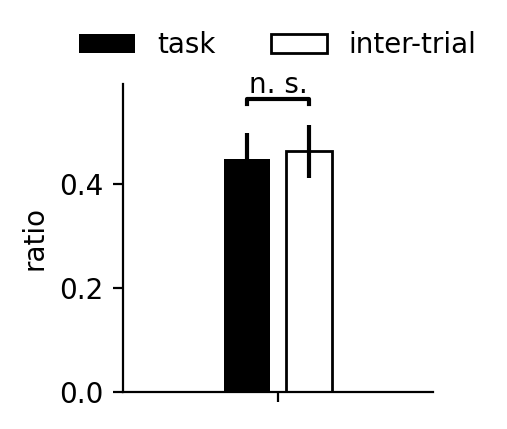

In [ ]:
plt.figure(figsize=(2, 2), dpi=200)

plt.bar([0.5 - 0.1], [count_states['stimOn_times'].mean()], yerr=[count_states['stimOn_times'].std()], color='black', width=0.15, label='task')
plt.bar([0.5 + 0.1], [count_states['stimOff_times'].mean()], yerr=[count_states['stimOff_times'].std()], color='white', width=0.15, edgecolor='black', label='inter-trial')

x_ii = 0.5
layer_p = sp.stats.ttest_ind(count_states['stimOn_times'], count_states['stimOff_times'])[1]
barplot_annotate_brackets(1, 2, layer_p,
                            np.array([x_ii - 0.1, x_ii - 0.1, x_ii + 0.1, x_ii + 0.1]),
                        [0.5, 0.5, 0.5, 0.5], dh=0.1, barh=.02, maxasterix=3)
# plt.xticks([x_ii], [br_group[0] + ' + ' + br_group[1]], rotation=30)
plt.xlim([0.0, 1.0])
plt.xticks([0.5], [''])
plt.legend(loc='lower center', bbox_to_anchor=(0.5, 1), ncol=2, frameon=False)
plt.ylabel('ratio')
sns.despine()
plt.show()

In [ ]:
np.argsort(np.array([3, 2, 1]))[-4:]

array([2, 1, 0])

In [ ]:
count_states = {}
for key in ['stimOn_times', 'stimOff_times']:
    count_states[key] = {}
    counts = []
    for rep in range(0, 30):

        hub_acronyms = []
        for comm in np.unique(community_keys_repeat_dict[key][rep]['comm']['communities_label']):
            comm_acronyms = community_keys_repeat_dict[key][rep]['comm']['communities_acronym'][np.argwhere(community_keys_repeat_dict[key][rep]['comm']['communities_label'] == comm).flatten()]
            comm_ids = community_keys_repeat_dict[key][rep]['comm']['communities'][np.argwhere(community_keys_repeat_dict[key][rep]['comm']['communities_label'] == comm).flatten()]
            comm_degrees = []
            for id in comm_ids:
                comm_degrees.append(max(community_keys_repeat_dict[key][rep]['degree']['AnyNet'][id], community_keys_repeat_dict[key][rep]['degree']['ViT'][id], community_keys_repeat_dict[key][rep]['degree']['RNN'][id]))
            hub_acronyms.append(comm_acronyms[np.argsort(np.array(comm_degrees)[-3:]).flatten()])
        hub_acronyms = np.array(hub_acronyms)
        layer_counter = 0
        for acronym_candi in hub_acronyms:
            hub_flag = False
            for acronym in acronym_candi:
                if hub_flag == True:
                    break
                for layer_num in ['1', '3', '4', '5', '6']:
                    if layer_num in acronym:
                        layer_counter += 1
                        hub_flag = True

        counts.append(layer_counter / len(hub_acronyms))
    count_states[key] = np.array(counts)

In [ ]:
acronym_candi

array(['VISam5', 'VISam2/3', 'VISam4'], dtype='<U10')

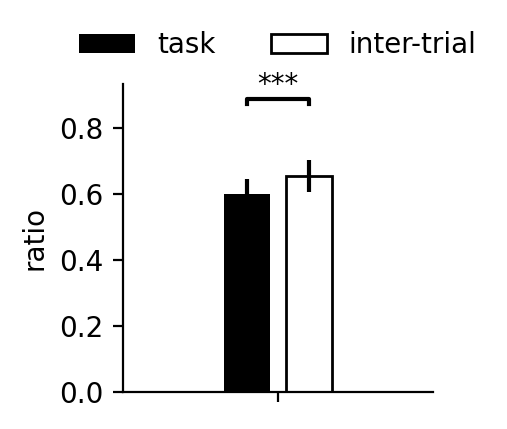

In [ ]:
plt.figure(figsize=(2, 2), dpi=200)

plt.bar([0.5 - 0.1], [count_states['stimOn_times'].mean()], yerr=[count_states['stimOn_times'].std()], color='black', width=0.15, label='task')
plt.bar([0.5 + 0.1], [count_states['stimOff_times'].mean()], yerr=[count_states['stimOff_times'].std()], color='white', width=0.15, edgecolor='black', label='inter-trial')

x_ii = 0.5
layer_p = sp.stats.ttest_ind(count_states['stimOn_times'], count_states['stimOff_times'])[1]
barplot_annotate_brackets(1, 2, layer_p,
                            np.array([x_ii - 0.1, x_ii - 0.1, x_ii + 0.1, x_ii + 0.1]),
                        [0.8, 0.8, 0.8, 0.8], dh=0.1, barh=.02, maxasterix=3)
# plt.xticks([x_ii], [br_group[0] + ' + ' + br_group[1]], rotation=30)
plt.xlim([0.0, 1.0])
plt.xticks([0.5], [''])
plt.legend(loc='lower center', bbox_to_anchor=(0.5, 1), ncol=2, frameon=False)
plt.ylabel('ratio')
sns.despine()
plt.show()

In [ ]:
'PH' in acronym

True

In [ ]:
layer_counter / len(hub_acronyms)

0.3488372093023256

In [ ]:
comm_ids

array([263, 311, 312, 447])

In [ ]:
key = 'stimOn_times'
rep = 0
top_num = 3
community_keys_repeat_dict[key][rep]

{'comm': {'communities': array([262, 264, 277, 239, 240, 241, 441, 242, 255, 265, 282, 285, 287,
         288, 289, 290, 291, 292, 302, 308, 334, 444, 446, 448, 449,  87,
          88,  89,  90,  91,  92, 278, 279, 283, 257, 261, 315, 442, 286,
         294, 295, 385, 386, 388, 389, 390, 391, 393, 394, 395, 396, 397,
         398, 399, 400, 401, 402, 403, 404, 406, 407, 408, 409, 410, 411,
         412, 413, 415, 417, 418, 419, 420, 454, 455, 456, 458, 459, 460,
         461, 462, 463, 464, 465, 467, 468, 469, 470, 471, 256, 258, 260,
         276, 297, 316, 317, 328, 329, 331, 332, 333, 335, 336, 337, 338,
         340, 341, 342, 343, 344, 346, 347, 350, 351, 355, 357, 358, 360,
         361, 362, 363, 364, 451, 453, 179, 319, 320, 321, 175, 180, 225,
         127, 128, 129, 130, 131, 132, 133, 134, 139, 213, 243,  15,  16,
          18,  19,  50,  51,  52, 236,   6,   7,   8,  12,  13,  36,  37,
         157, 158, 167,  55, 140, 141, 237, 137, 142, 149, 150, 151, 154,
         425, 1

In [ ]:
community_keys_repeat_dict['stimOn_times'][0]['degree']['AnyNet']

DegreeView({0: 5, 1: 41, 2: 35, 3: 38, 4: 56, 5: 99, 6: 142, 7: 86, 8: 50, 9: 50, 10: 66, 11: 148, 12: 117, 13: 36, 14: 2, 15: 17, 16: 23, 17: 51, 18: 79, 19: 9, 20: 42, 21: 47, 22: 73, 23: 64, 24: 153, 25: 38, 26: 26, 27: 56, 28: 43, 29: 43, 30: 58, 31: 23, 32: 0, 33: 18, 34: 25, 35: 39, 36: 71, 37: 39, 38: 24, 39: 65, 40: 53, 41: 81, 42: 46, 43: 26, 44: 42, 45: 48, 46: 56, 47: 86, 48: 41, 49: 28, 50: 20, 51: 30, 52: 15, 53: 20, 54: 36, 55: 9, 56: 19, 57: 34, 58: 91, 59: 66, 60: 32, 61: 8, 62: 22, 63: 33, 64: 24, 65: 3, 66: 0, 67: 0, 68: 30, 69: 20, 70: 0, 71: 0, 72: 0, 73: 54, 74: 0, 75: 0, 76: 13, 77: 6, 78: 15, 79: 0, 80: 40, 81: 9, 82: 11, 83: 5, 84: 0, 85: 6, 86: 4, 87: 39, 88: 56, 89: 38, 90: 34, 91: 57, 92: 24, 93: 32, 94: 30, 95: 36, 96: 84, 97: 58, 98: 29, 99: 88, 100: 100, 101: 105, 102: 131, 103: 108, 104: 69, 105: 12, 106: 3, 107: 6, 108: 46, 109: 24, 110: 38, 111: 60, 112: 44, 113: 66, 114: 52, 115: 20, 116: 14, 117: 15, 118: 115, 119: 44, 120: 16, 121: 11, 122: 15, 123: 

In [ ]:
resolution = 1.0

community_keys_repeat_dict = {}

for key in ['stimOn_times', 'stimOff_times']:

    dat_tem = {}
    for rep in range(0, 30):
        if key == 'stimOn_times':
            Mat_dict = Mat_dict_stim_repeat

        elif key == 'stimOff_times':
            Mat_dict = Mat_dict_rest_repeat


        community_number = []
        community_index = {}
        community_dat = {}
        for name in ['AnyNet', 'ViT', 'RNN']:
            X = copy.deepcopy(Mat_dict[rep][name])
            community_label, acronym_label, index = modularity_separation(X, resolution)
            community_number.append(len(np.unique(community_label)))
            community_index[name] = community_label

        communities = []
        communities_label = []
        communities_acronym = []
        ii = 0
        for community_ii_AnyNet in range(0, community_number[0]):
            for community_ii_ViT in range(0, community_number[1]):
                for community_ii_RNN in range(0, community_number[2]):
                    community0 = np.intersect1d(np.intersect1d(np.argwhere(community_index['AnyNet'] == community_ii_AnyNet).flatten(),
                                                    np.argwhere(community_index['ViT'] == community_ii_ViT).flatten()),
                                    np.argwhere(community_index['RNN'] == community_ii_RNN).flatten())
                    if len(community0) > 2:
                        communities.append(community0)
                        communities_acronym.append(np.array(acronym_list)[community0])
                        communities_label.append(ii * np.ones_like(community0))
                        ii = ii + 1

        communities = np.concat(communities)
        communities_label = np.concat(communities_label)
        communities_acronym = np.concat(communities_acronym)
        community_dat['communities'] = communities
        community_dat['communities_label'] = communities_label
        community_dat['communities_acronym'] = communities_acronym


        dat_tem[rep] = community_dat

    community_keys_repeat_dict[key] = dat_tem



In [ ]:
community_keys_repeat_dict['stimOff_times']

{0: {'communities': array([ 41, 130, 213, 101, 168, 183,  20,  21,  56,  57,  93,  94,  95,
          96, 100, 105, 116, 118, 195, 196,  26,  27,  28,  44,  99, 102,
         103, 169, 170, 171, 176, 225, 435,  39,  40, 108, 109,  38, 174,
         175, 178, 179, 319, 320, 321,  87, 110, 111, 112, 113, 184,  22,
          23,  24,  25,  45,  46,  47, 366, 380, 385, 386, 387, 388, 389,
         390, 391, 393, 394, 395, 396, 397, 398, 399, 400, 401, 402, 403,
         404, 405, 406, 407, 408, 409, 410, 411, 413, 415, 417, 418, 419,
         420, 454, 455, 456, 457, 458, 459, 460, 461, 462, 463, 464, 465,
         466, 467, 468, 469, 470, 471, 367, 368, 378, 322, 345, 356, 369,
         375, 379, 384,   3,   5,   6,   7,   8,  12,  13,  33,  34,  35,
          36,  37,  61,  62, 127, 128, 129, 131, 132, 133, 134, 137, 138,
         139, 140, 141, 142, 143, 146, 147, 150, 154, 155, 156, 157, 158,
         163, 165, 167, 226, 236, 425,  10,  30,  31, 162, 164, 237, 271,
         272, 300,  

In [ ]:
rep = 1
key = 'stimOff_times'
br_hub = 'MOp6a'
community_dict = community_dict_rest[resolution]
br_hub_mem0 = community_dict['communities_acronym'][np.argwhere(community_dict['communities_label'] == community_dict['communities_label'][np.argwhere(community_dict['communities_acronym'] == br_hub).flatten()]).flatten()]
community_dict = community_dict_stim[resolution]
br_hub_mem1 = community_dict['communities_acronym'][np.argwhere(community_dict['communities_label'] == community_dict['communities_label'][np.argwhere(community_dict['communities_acronym'] == br_hub).flatten()]).flatten()]



In [ ]:
br_hub_mem0

array(['FRP6a', 'MOp5', 'MOp6a', 'MOp6b', 'MOs6a', 'MOs6b', 'SSp-m2/3',
       'SSp-m4', 'SSp-m5', 'SSp-m6a', 'SSp-m6b', 'GU5', 'GU6a', 'ACAd5',
       'ACAd6a', 'ACAd6b', 'ACAv2/3', 'ACAv5', 'ACAv6a', 'ACAv6b', 'PL5',
       'PL6a', 'PL6b', 'ILA1', 'ILA2/3', 'ILA5', 'ILA6a', 'ORBl6a',
       'ORBm5', 'ORBm6a', 'ORBvl6a', 'AId5', 'AId6a', 'AId6b', 'AIp6b',
       'AIv2/3', 'AIv5', 'AIv6a', 'AIv6b', 'CLA', 'EPd', 'CP', 'ACB'],
      dtype='<U10')

In [ ]:
br_hub_mem1

array(['MOp5', 'MOp6a', 'MOp6b', 'SSp-n4', 'SSp-n6a', 'SSp-n6b',
       'SSp-m6a', 'SSp-m6b', 'ORBl5', 'ORBl6a', 'AId6a', 'AId6b', 'AIv5',
       'AIv6a', 'AIv6b', 'CLA'], dtype='<U10')

In [ ]:
resolution = 1.0
key = 'stimOn_times'
br_group = ['MOp6a', 'MOp6b']

for rep in range(0, 30):
    community_dict = community_keys_repeat_dict[key][rep]
    try:
        group_label = [community_dict['communities_label'][np.argwhere(community_dict['communities_acronym'] == acronym).flatten()] for acronym in br_group]
        if len(np.unique(np.array(group_label))) < len(br_group):
            print(1)
    except:
        continue


1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1


In [ ]:
rep = 0
key = 'stimOn_times'
br_group = ['MRN', 'VPM']

exist_flag = []
for rep in range(0, 30):
    community_dict = community_keys_repeat_dict[key][rep]
    try:
        group_label = [community_dict['communities_label'][np.argwhere(community_dict['communities_acronym'] == acronym).flatten()] for acronym in br_group]
        if len(np.unique(np.array(group_label))) == 1:
            exist_flag.append(1)
        else:
            exist_flag.append(0)

    except:
        exist_flag.append(0)
        continue

print(np.array(exist_flag).sum())
p1 = np.array(exist_flag).sum() / 30

key = 'stimOff_times'
exist_flag = []
for rep in range(0, 30):
    community_dict = community_keys_repeat_dict[key][rep]
    try:
        group_label = [community_dict['communities_label'][np.argwhere(community_dict['communities_acronym'] == acronym).flatten()] for acronym in br_group]
        if len(np.unique(np.array(group_label))) == 1:
            exist_flag.append(1)
        else:
            exist_flag.append(0)

    except:
        exist_flag.append(0)
        continue

print(np.array(exist_flag).sum())
p2 = np.array(exist_flag).sum() / 30

print((1 - p1) * p2)
print(p1)
print(p2)

24
3
0.019999999999999997
0.8
0.1


In [ ]:
rep = 0
key = 'stimOn_times'
br_group = ['MRN', 'VM']

exist_flag = []
for rep in range(0, 30):
    community_dict = community_keys_repeat_dict[key][rep]
    try:
        group_label = [community_dict['communities_label'][np.argwhere(community_dict['communities_acronym'] == acronym).flatten()] for acronym in br_group]
        if len(np.unique(np.array(group_label))) == 1:
            exist_flag.append(1)
        else:
            exist_flag.append(0)

    except:
        exist_flag.append(0)
        continue

s1 = np.array(exist_flag).sum()

key = 'stimOff_times'
exist_flag = []
for rep in range(0, 30):
    community_dict = community_keys_repeat_dict[key][rep]
    try:
        group_label = [community_dict['communities_label'][np.argwhere(community_dict['communities_acronym'] == acronym).flatten()] for acronym in br_group]
        if len(np.unique(np.array(group_label))) == 1:
            exist_flag.append(1)
        else:
            exist_flag.append(0)

    except:
        exist_flag.append(0)
        continue

s2 = np.array(exist_flag).sum()

from scipy.stats import fisher_exact
import numpy as np

# Sample data:
count1, nobs1 = s1, 30
count2, nobs2 = s2, 30

# Create a 2x2 contingency table:
# Row 1: successes and failures for group 1
# Row 2: successes and failures for group 2
table = np.array([
    [count1, nobs1 - count1],
    [count2, nobs2 - count2]
])

# Perform Fisher's exact test
# The alternative hypothesis can be 'two-sided', 'less', or 'greater'.
odds_ratio, p_value = fisher_exact(table, alternative='two-sided')

print(f"Odds Ratio: {odds_ratio}")
print(f"P-value: {p_value}")

# Interpretation:
alpha = 0.05
if p_value < alpha:
    print("Reject the null hypothesis: there is a significant difference between the two proportions.")
else:
    print("Fail to reject the null hypothesis: there is not enough evidence to suggest a significant difference between the two proportions.")


Odds Ratio: 0.0
P-value: 1.0
Fail to reject the null hypothesis: there is not enough evidence to suggest a significant difference between the two proportions.


In [ ]:
from scipy.stats import fisher_exact
import numpy as np

# Sample data:
count1, nobs1 = 24, 30
count2, nobs2 = 3, 30

# Create a 2x2 contingency table:
# Row 1: successes and failures for group 1
# Row 2: successes and failures for group 2
table = np.array([
    [count1, nobs1 - count1],
    [count2, nobs2 - count2]
])

# Perform Fisher's exact test
# The alternative hypothesis can be 'two-sided', 'less', or 'greater'.
odds_ratio, p_value = fisher_exact(table, alternative='two-sided')

print(f"Odds Ratio: {odds_ratio}")
print(f"P-value: {p_value}")

# Interpretation:
alpha = 0.05
if p_value < alpha:
    print("Reject the null hypothesis: there is a significant difference between the two proportions.")
else:
    print("Fail to reject the null hypothesis: there is not enough evidence to suggest a significant difference between the two proportions.")


Odds Ratio: 36.0
P-value: 5.6213814618317425e-08
Reject the null hypothesis: there is a significant difference between the two proportions.


In [ ]:
rep = 0
key = 'stimOn_times'
br_group = ['MRN', 'VPM']

exist_flag = []
for rep in range(0, 30):
    community_dict = community_keys_repeat_dict[key][rep]
    try:
        group_label = [community_dict['communities_label'][np.argwhere(community_dict['communities_acronym'] == acronym).flatten()] for acronym in br_group]
        if len(np.unique(np.array(group_label))) == 1:
            exist_flag.append(1)
        else:
            exist_flag.append(0)

    except:
        exist_flag.append(0)
        continue

p = np.array(exist_flag).sum() / 30
print(p)

0.8


In [ ]:
0.23333 * 0.3

0.069999

In [ ]:
resolution = 1.0
p_dict = {}
for key in ['stimOff_times', 'stimOn_times']:
    p_dict[key] = {}
    p_list = []
    for acronym0 in ['SSp-un1', 'PIL', 'NB', 'SNr', 'VTA', 'SCiw', 'ND', 'APN', 'NOT',
       'NPC', 'OP', 'PPT', 'RPF', 'III', 'Pa4', 'MT', 'SNc', 'IPA',
       'IPDL', 'RL', 'CLI', 'MRN']:

        for acronym1 in ['VAL', 'VM', 'VPLpc', 'VPM', 'PoT', 'LP', 'PO', 'SGN', 'Eth', 'LD','CL']:

            br_group = [acronym0, acronym1]

            exist_flag = []
            for rep in range(0, 30):
                community_dict = community_keys_repeat_dict[key][rep]
                try:
                    group_label = [community_dict['communities_label'][np.argwhere(community_dict['communities_acronym'] == acronym).flatten()] for acronym in br_group]
                    if len(np.unique(np.array(group_label))) == 1:
                        exist_flag.append(1)
                    else:
                        exist_flag.append(0)

                except:
                    exist_flag.append(0)
                    continue

            p = np.array(exist_flag).sum() / 30
            p_list.append(p)

    p_dict[key] = np.array(p_list)


In [ ]:
p_dict

{'stimOff_times': array([0.03333333, 0.1       ]),
 'stimOn_times': array([0. , 0.8])}

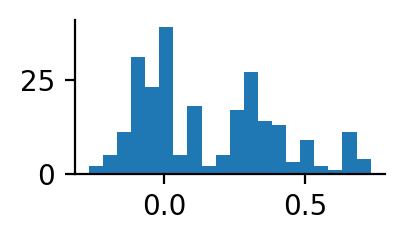

In [ ]:
plt.figure(figsize=(2, 1), dpi=200)
plt.hist([p_dict['stimOn_times'] - p_dict['stimOff_times']], bins=20)
sns.despine()
plt.show()

In [ ]:
exist_flag

[1, 1, 0, 0, 1]

In [ ]:
group_label

[array([14]), array([19])]

In [ ]:
or_dict = {}

for key in ['stimOff_times', 'stimOn_times']:
    or_dict[key] = {}
    for br_selec in [['MRN', 'LP']]:

        overlap_ratio = []
        for rep in range(0, 30):
            try:
                br_pool0 = []
                br_pool1 = []
                for acronym in br_selec:
                    br_hub = acronym
                    if key == 'stimOff_times':
                        community_dict = community_dict_rest[resolution]
                    elif key == 'stimOn_times':
                        community_dict = community_dict_stim[resolution]


                    br_pool0.append(community_dict['communities_acronym'][np.argwhere(community_dict['communities_label'] == community_dict['communities_label'][np.argwhere(community_dict['communities_acronym'] == br_hub).flatten()]).flatten()])
                    community_dict = community_keys_repeat_dict[key][rep]
                    br_pool1.append(community_dict['communities_acronym'][np.argwhere(community_dict['communities_label'] == community_dict['communities_label'][np.argwhere(community_dict['communities_acronym'] == br_hub).flatten()]).flatten()])

                br_pool0 = np.concat(br_pool0)
                br_pool1 = np.concat(br_pool1)
                print(f"rep: {rep}")
                print(len(np.intersect1d(br_pool0, br_pool1)) / len(br_pool0))
                overlap_ratio.append(len(np.intersect1d(br_pool0, br_pool1)) / len(br_pool0))

            except:
                # print(f"rep: {rep}")
                # print(0)
                # overlap_ratio.append(0)
                continue

        overlap_ratio = np.array(overlap_ratio)
        or_dict[key][str(br_selec)] = {}
        or_dict[key][str(br_selec)] = overlap_ratio
        print(f"{key}, {br_selec}>>>>>>>>>>>>>>>>>>")
        print(overlap_ratio.mean())

rep: 0
0.24242424242424243
rep: 1
0.5757575757575758
rep: 2
0.21212121212121213
rep: 4
0.5151515151515151
rep: 6
0.5151515151515151
rep: 7
0.30303030303030304
rep: 8
0.5757575757575758
rep: 9
0.06060606060606061
rep: 10
0.8181818181818182
rep: 12
0.5454545454545454
rep: 13
0.30303030303030304
rep: 14
0.7878787878787878
rep: 15
0.3333333333333333
rep: 16
0.7878787878787878
rep: 18
0.6060606060606061
rep: 19
0.696969696969697
rep: 20
0.8484848484848485
rep: 21
0.30303030303030304
rep: 23
0.7878787878787878
rep: 27
0.8181818181818182
rep: 28
0.36363636363636365
rep: 29
0.36363636363636365
stimOff_times, ['MRN', 'LP']>>>>>>>>>>>>>>>>>>
0.5165289256198347
rep: 0
0.40476190476190477
rep: 1
0.42857142857142855
rep: 2
0.39285714285714285
rep: 3
0.42857142857142855
rep: 4
0.4642857142857143
rep: 5
0.44047619047619047
rep: 6
0.4642857142857143
rep: 7
0.4642857142857143
rep: 8
0.30952380952380953
rep: 9
0.38095238095238093
rep: 11
0.4642857142857143
rep: 13
0.4880952380952381
rep: 15
0.4523809523

In [ ]:
or_dict = {}

for key in ['stimOff_times', 'stimOn_times']:
    or_dict[key] = {}
    for br_selec in [['MRN'], ['LP']]:

        overlap_ratio = []
        for rep in range(0, 30):
            try:
                br_pool0 = []
                br_pool1 = []
                for acronym in br_selec:
                    br_hub = acronym
                    if key == 'stimOff_times':
                        community_dict = community_dict_rest[resolution]
                    elif key == 'stimOn_times':
                        community_dict = community_dict_stim[resolution]


                    br_pool0.append(community_dict['communities_acronym'][np.argwhere(community_dict['communities_label'] == community_dict['communities_label'][np.argwhere(community_dict['communities_acronym'] == br_hub).flatten()]).flatten()])
                    community_dict = community_keys_repeat_dict[key][rep]
                    br_pool1.append(community_dict['communities_acronym'][np.argwhere(community_dict['communities_label'] == community_dict['communities_label'][np.argwhere(community_dict['communities_acronym'] == br_hub).flatten()]).flatten()])

                br_pool0 = np.concat(br_pool0)
                br_pool1 = np.concat(br_pool1)
                print(f"rep: {rep}")
                print(max(len(np.intersect1d(br_pool0, br_pool1)) / len(br_pool0), len(np.intersect1d(br_pool0, br_pool1)) / len(br_pool1)))
                overlap_ratio.append(max(len(np.intersect1d(br_pool0, br_pool1)) / len(br_pool0), len(np.intersect1d(br_pool0, br_pool1)) / len(br_pool1)))

            except:
                overlap_ratio.append(0)
                continue

        overlap_ratio = np.array(overlap_ratio)
        or_dict[key][str(br_selec)] = {}
        or_dict[key][str(br_selec)] = overlap_ratio
        print(f"{key}, {br_selec}>>>>>>>>>>>>>>>>>>")
        print(overlap_ratio.mean())

rep: 0
0.8333333333333334
rep: 1
0.9473684210526315
rep: 2
0.18181818181818182
rep: 3
1.0
rep: 4
0.9375
rep: 5
0.9090909090909091
rep: 6
0.8181818181818182
rep: 7
0.6666666666666666
rep: 8
0.8181818181818182
rep: 9
0.3333333333333333
rep: 10
0.9090909090909091
rep: 11
0.9090909090909091
rep: 12
1.0
rep: 13
1.0
rep: 14
0.4444444444444444
rep: 15
1.0
rep: 16
0.9545454545454546
rep: 17
0.8636363636363636
rep: 18
1.0
rep: 19
0.9545454545454546
rep: 20
0.9166666666666666
rep: 21
0.2727272727272727
rep: 23
0.9090909090909091
rep: 24
1.0
rep: 25
0.85
rep: 26
1.0
rep: 27
0.8636363636363636
rep: 28
0.8
rep: 29
0.9
stimOff_times, ['MRN']>>>>>>>>>>>>>>>>>>
0.7997649743044479
rep: 0
0.75
rep: 1
0.16666666666666666
rep: 2
0.3333333333333333
rep: 4
0.3333333333333333
rep: 6
0.7272727272727273
rep: 7
0.7272727272727273
rep: 8
0.3333333333333333
rep: 9
0.25
rep: 10
0.2
rep: 12
0.3333333333333333
rep: 13
0.75
rep: 14
0.7272727272727273
rep: 15
0.7272727272727273
rep: 16
0.4
rep: 18
0.3333333333333333
r

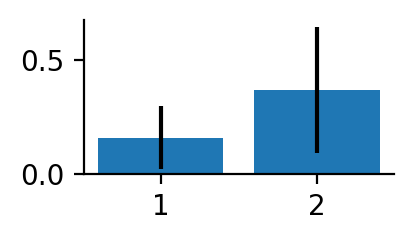

In [ ]:
plt.figure(figsize=(2, 1), dpi=200)
plt.bar([1, 2], [or_dict['stimOn_times']["['LP']"].mean(), or_dict['stimOff_times']["['LP']"].mean()],
        yerr=[or_dict['stimOn_times']["['LP']"].std(), or_dict['stimOff_times']["['LP']"].std()])
sns.despine()
plt.show()

In [ ]:
or_dict

{'stimOff_times': {"['MRN', 'LP']": array([0.8       , 0.76      , 0.21212121, 0.        , 0.89473684,
         0.        , 0.51515152, 0.52631579, 0.76      , 0.28571429,
         0.81818182, 0.        , 0.9       , 0.90909091, 0.78787879,
         0.64705882, 0.92857143, 0.        , 0.90909091, 0.88461538,
         0.84848485, 0.3030303 , 0.        , 0.83870968, 0.        ,
         0.        , 0.        , 0.81818182, 0.75      , 0.70588235]),
  "['MRN']": array([0.83333333, 0.94736842, 0.18181818, 1.        , 0.9375    ,
         0.90909091, 0.81818182, 0.66666667, 0.81818182, 0.33333333,
         0.90909091, 0.90909091, 1.        , 1.        , 0.44444444,
         1.        , 0.95454545, 0.86363636, 1.        , 0.95454545,
         0.91666667, 0.27272727, 0.        , 0.90909091, 1.        ,
         0.85      , 1.        , 0.86363636, 0.8       , 0.9       ]),
  "['LP']": array([0.75      , 0.16666667, 0.33333333, 0.        , 0.33333333,
         0.        , 0.72727273, 0.72727273,

In [ ]:
br_pool1

array(['VPLpc', 'PoT', 'SPFp', 'MGm', 'LP', 'SGN', 'Eth', 'PS', 'LPO',
       'STN', 'PT', 'NOT', 'NPC', 'OP', 'PPT', 'RPF', 'RL', 'MRN'],
      dtype='<U10')

In [ ]:
acronyms_hub = community_dict_rest[resolution]['communities_acronym']
for rep in range(0, 10):
    acronyms_hub = np.intersect1d(acronyms_hub, community_keys_repeat_dict[key][rep]['communities_acronym'])

for acronym in acronyms_hub:
    print(community_dict_rest[resolution]['communities_label'][np.argwhere(community_dict_rest[resolution]['communities_acronym'] == acronym).flatten()])

[2]
[2]
[2]
[17]
[2]
[2]
[2]
[2]
[18]
[12]
[2]
[2]
[2]
[2]
[2]
[0]
[0]
[0]
[10]
[10]
[14]
[3]
[21]
[21]
[21]
[21]
[21]
[21]
[21]
[18]
[28]
[9]
[9]
[0]
[0]
[2]
[0]
[0]
[0]
[0]
[0]
[7]
[0]
[29]
[0]
[0]
[10]
[10]
[2]
[0]
[2]
[2]
[0]
[12]
[0]
[15]
[17]
[14]
[2]
[2]
[2]
[13]
[0]
[0]
[14]
[14]
[15]
[12]
[0]
[0]
[0]
[19]
[10]
[12]
[0]
[0]
[18]
[0]
[0]
[0]
[2]
[2]
[2]
[2]
[18]
[14]
[18]
[0]
[14]
[0]
[14]
[0]
[14]
[10]
[2]
[2]
[10]
[0]
[0]
[22]
[0]
[0]
[0]
[13]
[2]
[2]
[2]
[12]
[14]
[13]
[0]
[0]
[12]
[12]
[12]
[12]
[0]
[0]
[12]
[19]
[9]
[12]
[12]
[14]
[15]
[4]
[3]
[3]
[3]
[3]
[12]
[12]
[14]
[3]
[3]
[3]
[19]
[0]
[12]
[14]
[14]
[13]
[13]
[0]
[0]
[0]
[0]
[6]
[6]
[5]
[2]
[2]
[2]
[6]
[6]
[13]
[6]
[6]
[21]
[21]
[12]
[12]
[0]
[0]
[21]
[21]
[22]
[22]
[27]
[6]
[6]
[6]
[6]
[9]
[3]
[3]
[3]
[3]
[5]
[3]
[4]
[4]
[4]
[12]
[21]
[14]
[0]
[12]
[0]
[0]


In [ ]:
'CA1' in acronyms_hub

True

In [ ]:
br_hub_mem0

array(['VAL', 'VM', 'VPLpc', 'VPM', 'PoT', 'LP', 'PO', 'SGN', 'Eth', 'LD',
       'CL'], dtype='<U10')

In [ ]:
np.argwhere(community_keys_repeat_dict['stimOff_times'][9]['communities_acronym'] == br_hub).flatten()

array([], dtype=int64)

In [ ]:
br_hub_mem0

array(['VAL', 'VM', 'VPLpc', 'VPM', 'PoT', 'LP', 'PO', 'SGN', 'Eth', 'LD',
       'CL'], dtype='<U10')

In [ ]:
br_hub_mem1

array(['VPLpc', 'PoT', 'SPFp', 'MGm', 'LP', 'SGN', 'Eth', 'PS', 'LPO',
       'STN'], dtype='<U10')

In [ ]:
community_keys_repeat_dict[key][rep] = community_dat

KeyError: 'stimOn_times'